In [ ]:
# %pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)
You should consider upgrading via the '/Users/macbook/Documents/Flower-prediction/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, mean_squared_error, r2_score,
    roc_curve, auc
)

# Traditional ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Boosting
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

import joblib

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130

os.makedirs("../visualizations/soil_prediction/eda", exist_ok=True)
os.makedirs("../visualizations/soil_prediction/models", exist_ok=True)
os.makedirs("../models/soil_prediction", exist_ok=True)

print("All imports successful.")

All imports successful.


In [17]:
import kagglehub

path = kagglehub.dataset_download("shankarpriya2913/crop-and-soil-dataset")
df = pd.read_csv(os.path.join(path, "data_core.csv"))

# Normalize column names
df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(8000, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [18]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types & Nulls ===")
df.info()

print("\n=== Descriptive Statistics ===")
df.describe(include="all").T

=== Shape ===
(8000, 9)

=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temparature      8000 non-null   float64
 1   Humidity         8000 non-null   float64
 2   Moisture         8000 non-null   float64
 3   Soil Type        8000 non-null   object 
 4   Crop Type        8000 non-null   object 
 5   Nitrogen         8000 non-null   int64  
 6   Potassium        8000 non-null   int64  
 7   Phosphorous      8000 non-null   int64  
 8   Fertilizer Name  8000 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 562.6+ KB

=== Descriptive Statistics ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Temparature,8000.0,NaN,NaN,NaN,30.338895,4.478262,20.0,27.05,30.24,33.46,40.0
Humidity,8000.0,NaN,NaN,NaN,59.210731,8.177366,40.02,53.2775,59.11,65.0825,80.0
Moisture,8000.0,NaN,NaN,NaN,43.580862,12.596156,20.0,33.9675,42.25,52.95,70.0
Soil Type,8000,5,Clayey,1623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop Type,8000,11,Sugarcane,763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nitrogen,8000.0,NaN,NaN,NaN,18.429125,11.852406,0.0,9.0,14.0,26.0,46.0
Potassium,8000.0,NaN,NaN,NaN,3.916375,5.494807,0.0,0.0,1.0,5.0,23.0
Phosphorous,8000.0,NaN,NaN,NaN,18.5125,13.244113,0.0,8.0,18.0,30.0,46.0
Fertilizer Name,8000,7,14-35-14,1188,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values per column:
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

Duplicate rows: 0


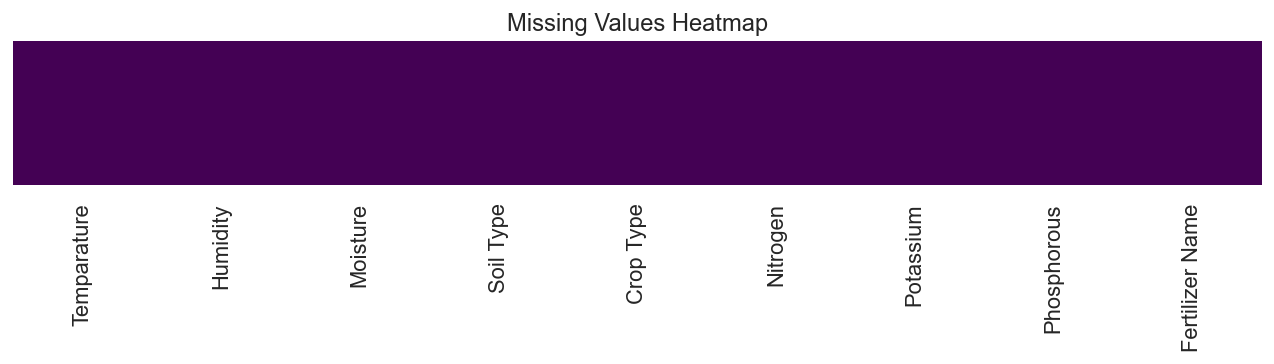

In [20]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Visualize missing values heatmap
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

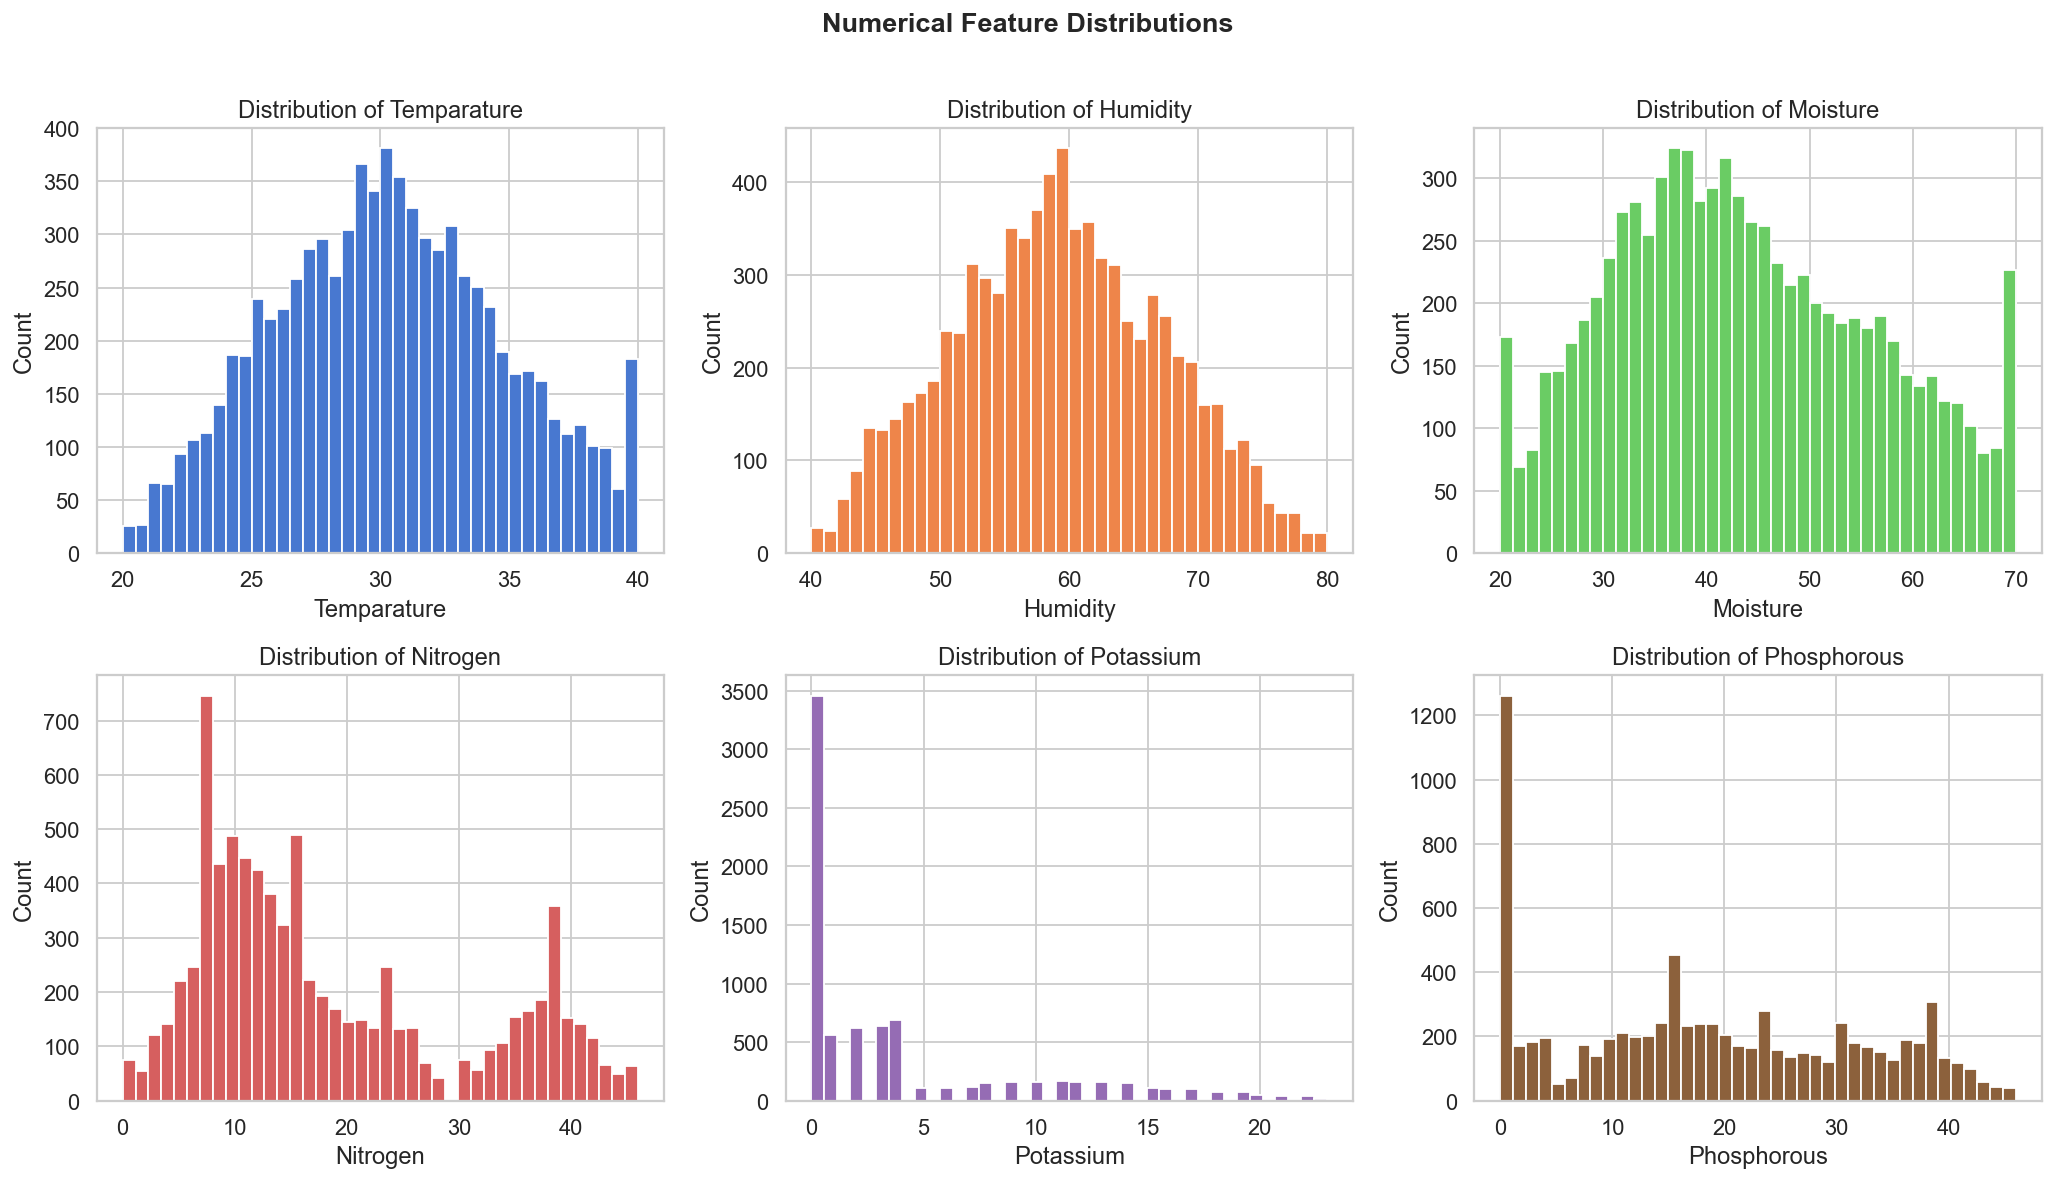

In [22]:
num_cols = ["Temparature", "Humidity", "Moisture", "Nitrogen", "Potassium", "Phosphorous"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, edgecolor="white", color=sns.color_palette("muted")[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.suptitle("Numerical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/02_numerical_distributions.png", bbox_inches="tight")
plt.show()

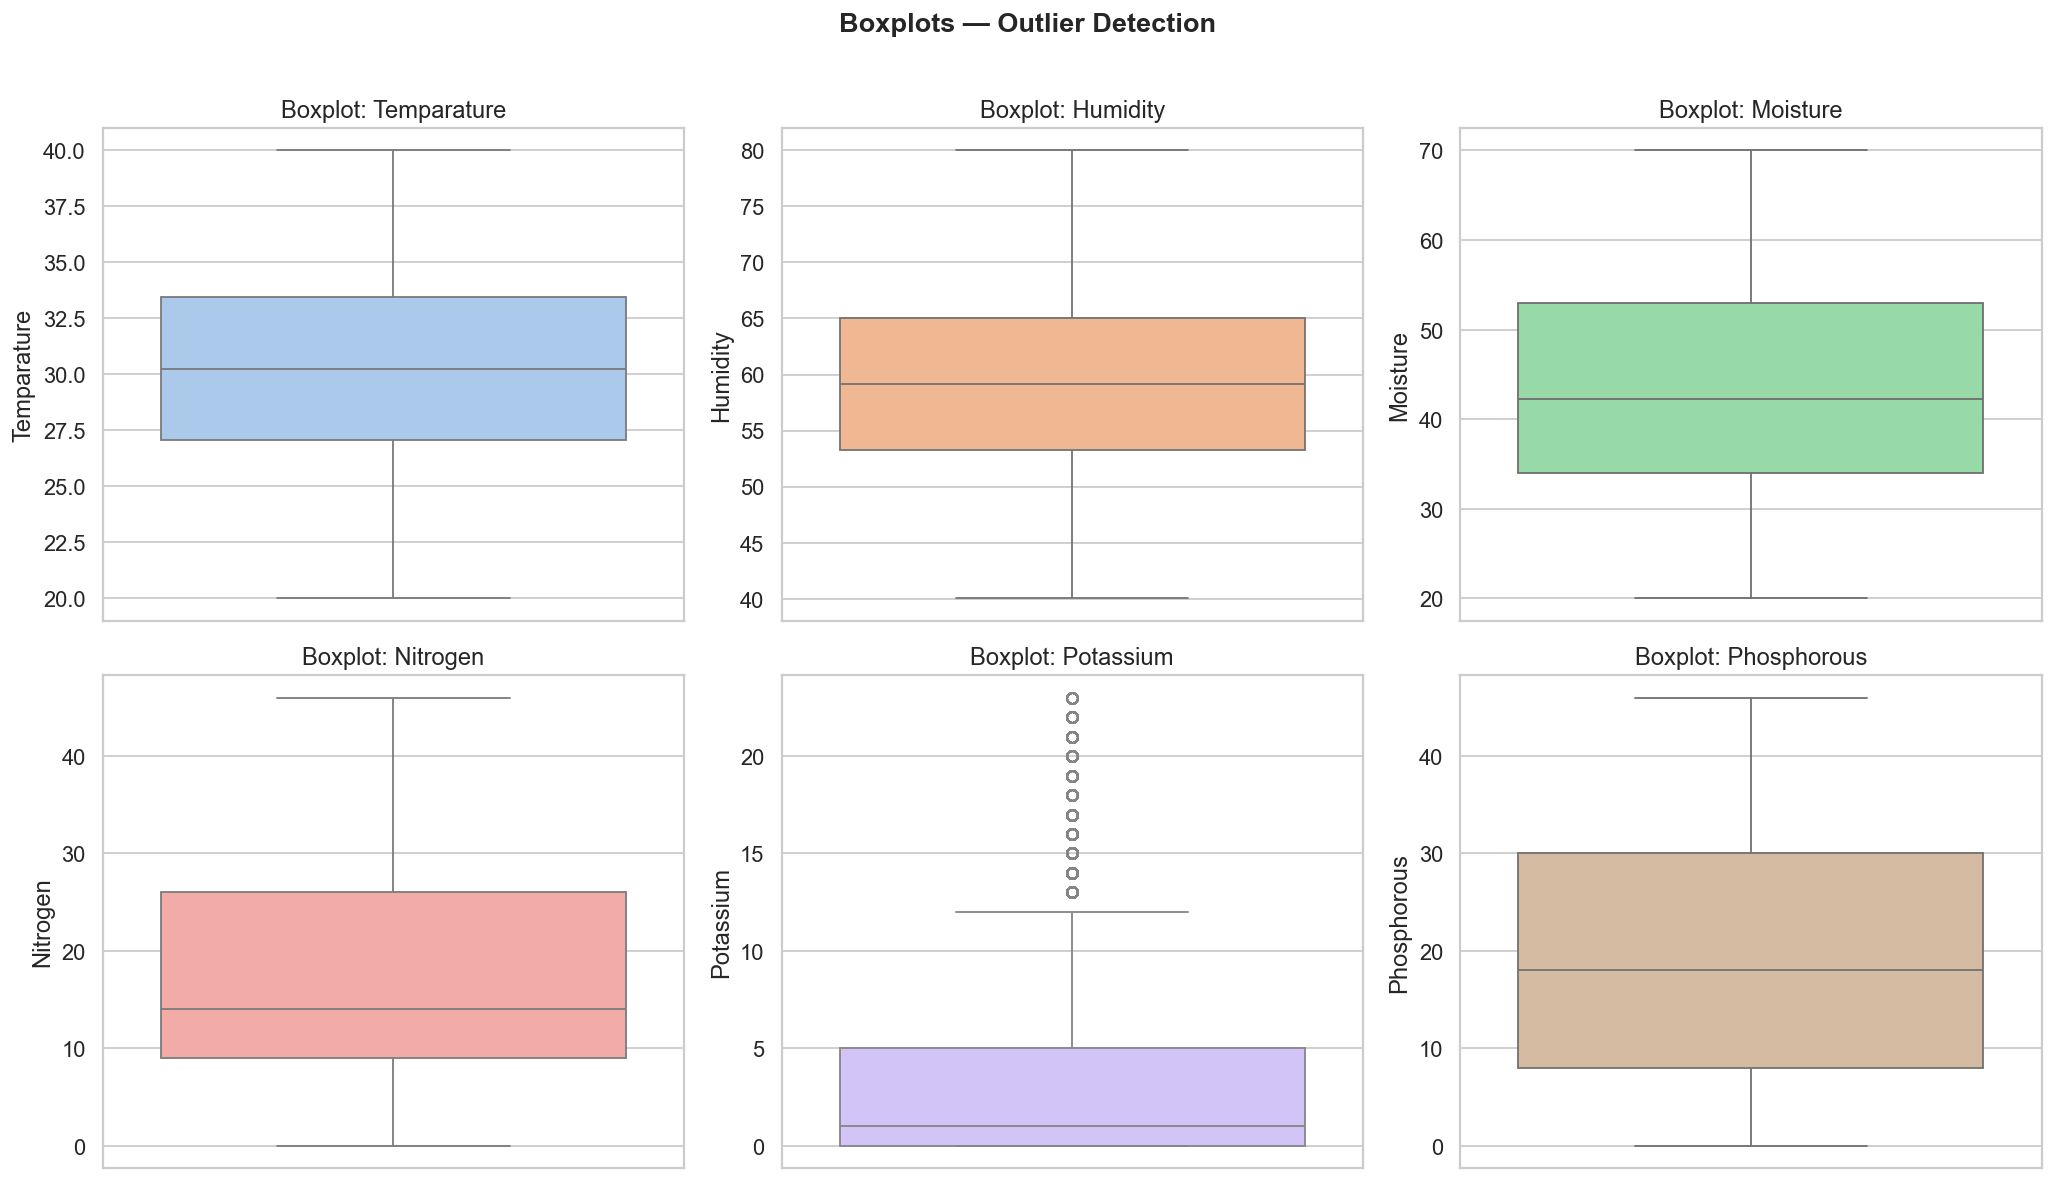

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette("pastel")[i])
    axes[i].set_title(f"Boxplot: {col}")

plt.suptitle("Boxplots — Outlier Detection", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/03_boxplots.png", bbox_inches="tight")
plt.show()

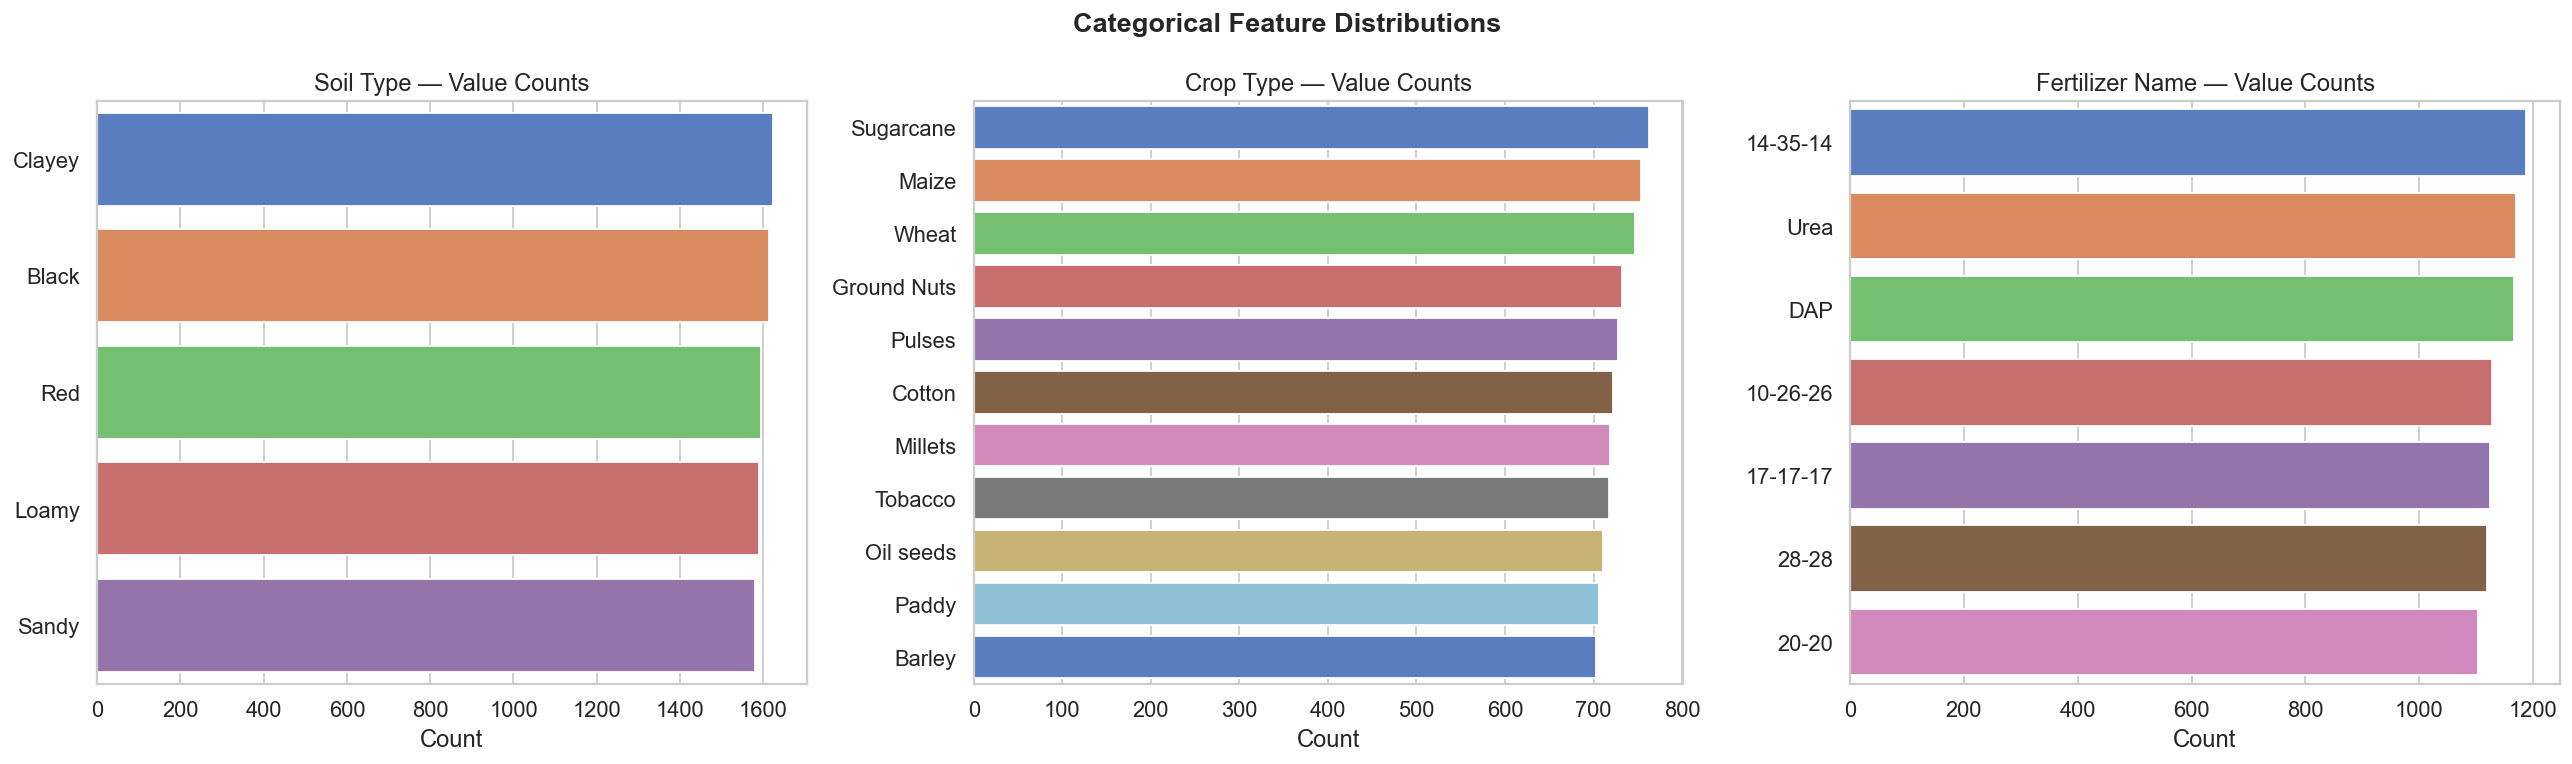

In [24]:
cat_cols = ["Soil Type", "Crop Type", "Fertilizer Name"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette="muted")
    axes[i].set_title(f"{col} — Value Counts")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/04_categorical_distributions.png", bbox_inches="tight")
plt.show()

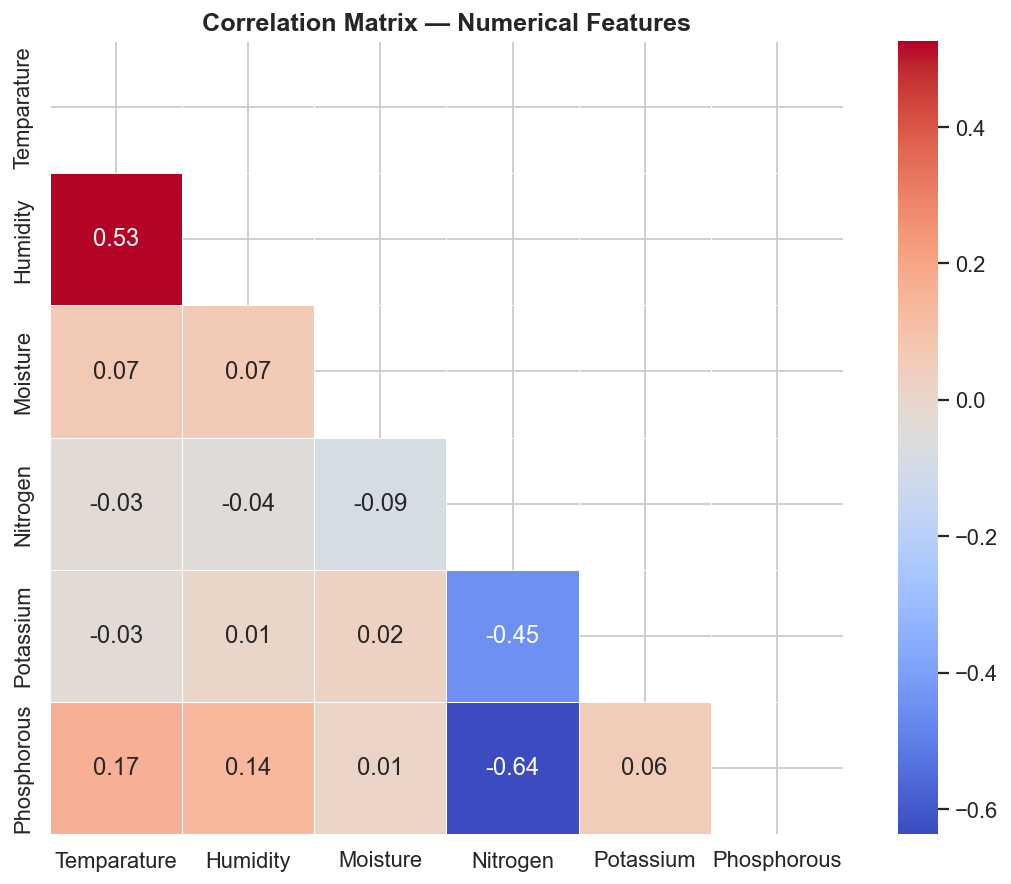

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Correlation Matrix — Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/05_correlation_heatmap.png")
plt.show()

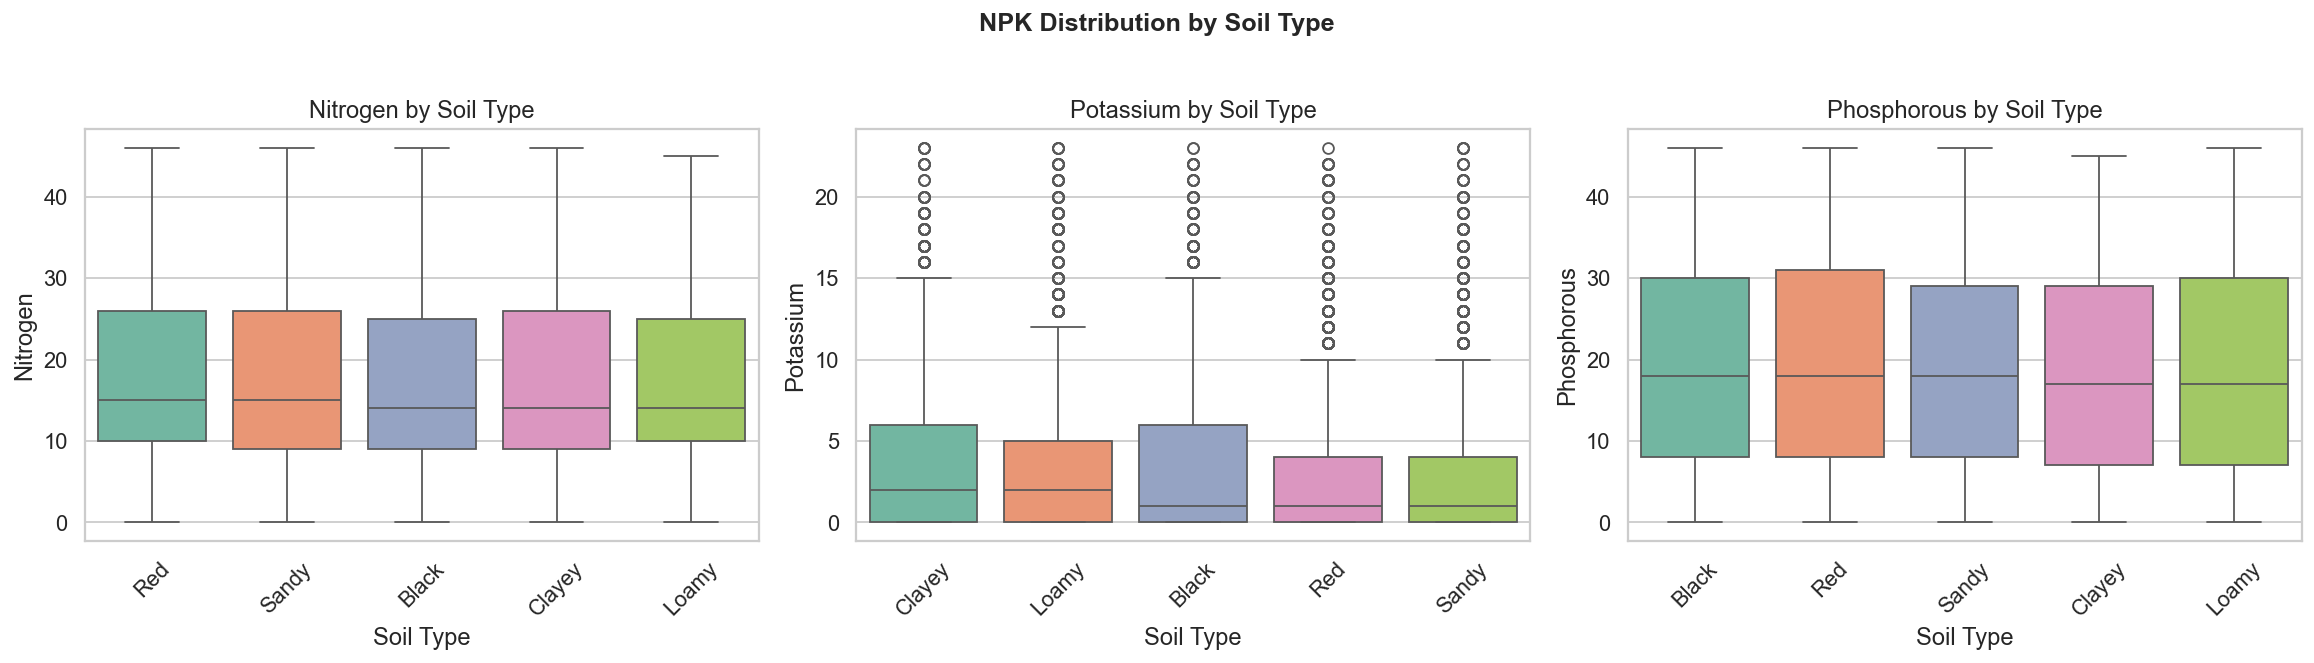

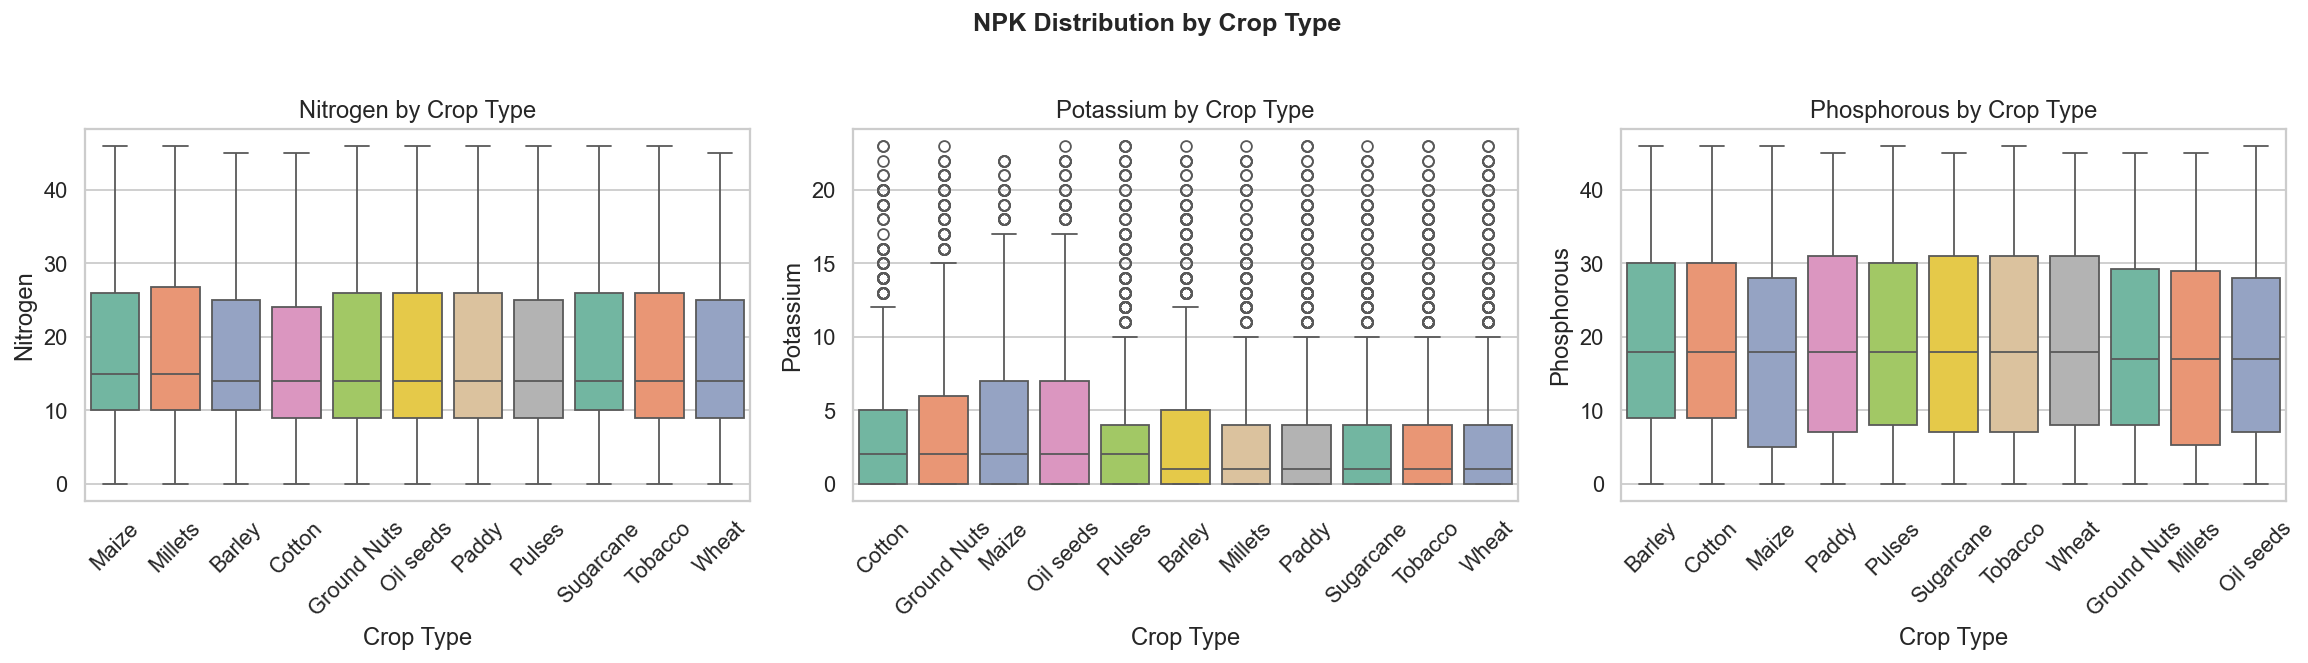

In [28]:
# EDA: NPK by Soil Type & Crop Type
for target_col in ["Soil Type", "Crop Type"]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, nutrient in enumerate(["Nitrogen", "Potassium", "Phosphorous"]):
        order = df.groupby(target_col)[nutrient].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=target_col, y=nutrient, ax=axes[i],
                    order=order, palette="Set2")
        axes[i].set_title(f"{nutrient} by {target_col}")
        axes[i].tick_params(axis="x", rotation=45)

    plt.suptitle(f"NPK Distribution by {target_col}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    safe_name = target_col.lower().replace(" ", "_")
    plt.savefig(f"../visualizations/soil_prediction/eda/06_npk_by_{safe_name}.png", bbox_inches="tight")
    plt.show()

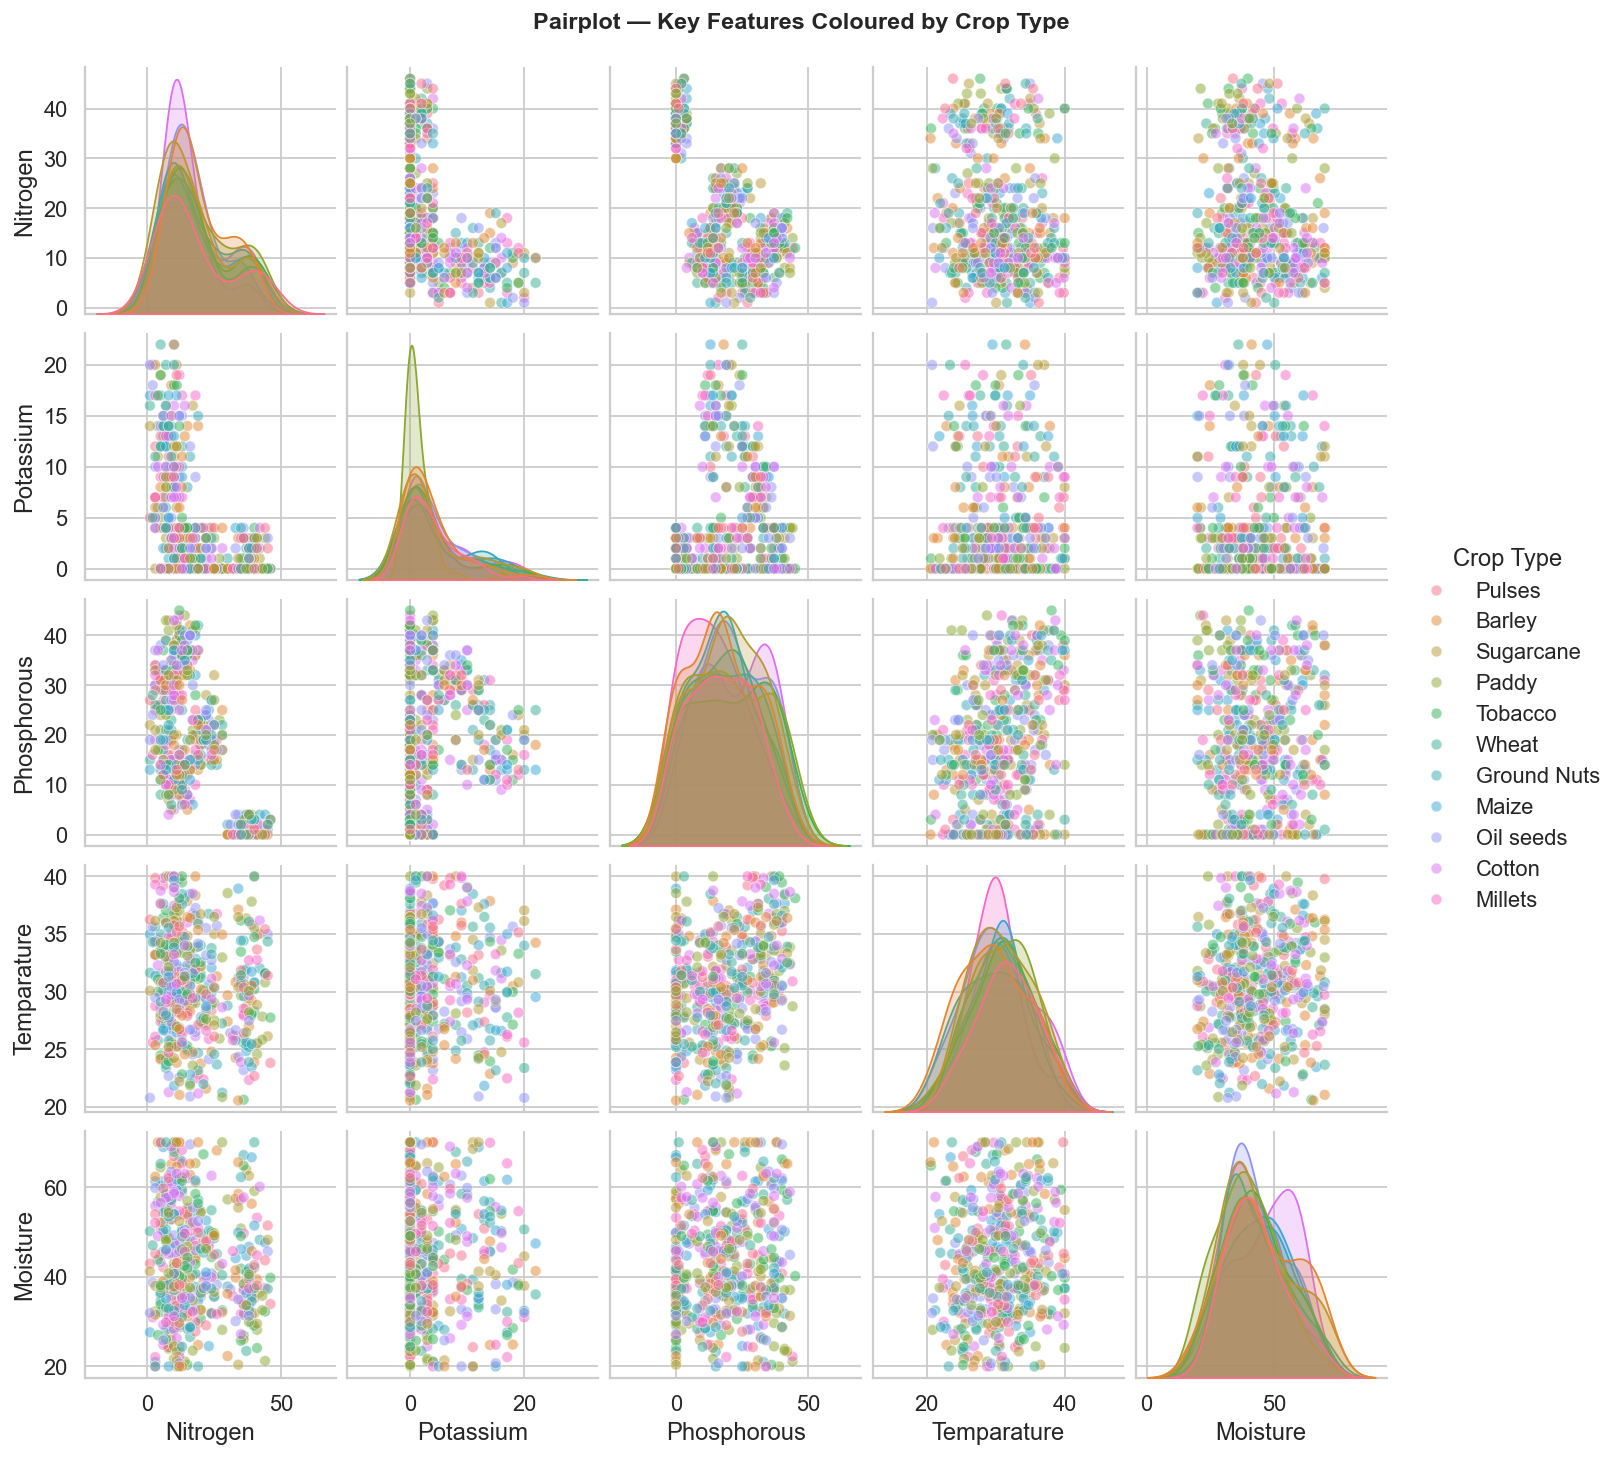

In [30]:
# EDA: Pairplot (NPK + Nutrients)
pair_df = df[["Nitrogen", "Potassium", "Phosphorous", "Temparature", "Moisture", "Crop Type"]].copy()
pair_df = pair_df.sample(500, random_state=42)  # sample for speed

g = sns.pairplot(pair_df, hue="Crop Type", diag_kind="kde", plot_kws={"alpha": 0.5}, height=2.2)
g.fig.suptitle("Pairplot — Key Features Coloured by Crop Type", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("../visualizations/soil_prediction/eda/07_pairplot.png", bbox_inches="tight")
plt.show()

# Feature Engineering & Shared Preprocessing

In [31]:
df_model = df.copy()

# --- Derived features ---
df_model["NPK_sum"]   = df_model["Nitrogen"] + df_model["Potassium"] + df_model["Phosphorous"]
df_model["N_P_ratio"] = df_model["Nitrogen"]   / (df_model["Phosphorous"] + 1)
df_model["N_K_ratio"] = df_model["Nitrogen"]   / (df_model["Potassium"]   + 1)

# --- Task 1 target: Soil Health Risk ---
# Rule-based labelling using N, P, K thresholds (domain heuristic)
def soil_risk_label(row):
    n, p, k = row["Nitrogen"], row["Phosphorous"], row["Potassium"]
    deficient = sum([n < 20, p < 10, k < 10])
    if deficient >= 2:
        return "High Risk"
    elif deficient == 1:
        return "Medium Risk"
    else:
        return "Low Risk"

df_model["Soil_Risk"] = df_model.apply(soil_risk_label, axis=1)

# --- Task 4 target: Salinity Stress (using Moisture as proxy for EC-like stress) ---
# High Moisture + extreme Humidity → stress flag
moisture_thresh = df_model["Moisture"].quantile(0.80)
humidity_thresh = df_model["Humidity"].quantile(0.75)
df_model["Salinity_Stress"] = (
    (df_model["Moisture"] > moisture_thresh) &
    (df_model["Humidity"] > humidity_thresh)
).astype(int)

# --- Encode categoricals ---
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fert = LabelEncoder()

df_model["Soil_Type_enc"]  = le_soil.fit_transform(df_model["Soil Type"])
df_model["Crop_Type_enc"]  = le_crop.fit_transform(df_model["Crop Type"])
df_model["Fert_Name_enc"]  = le_fert.fit_transform(df_model["Fertilizer Name"])

print("New columns added:")
print([c for c in df_model.columns if c not in df.columns])
df_model.head(3)

New columns added:
['NPK_sum', 'N_P_ratio', 'N_K_ratio', 'Soil_Risk', 'Salinity_Stress', 'Soil_Type_enc', 'Crop_Type_enc', 'Fert_Name_enc']


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,NPK_sum,N_P_ratio,N_K_ratio,Soil_Risk,Salinity_Stress,Soil_Type_enc,Crop_Type_enc,Fert_Name_enc
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea,37,37.000000,37.0,High Risk,0,4,3,6
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP,48,0.324324,12.0,High Risk,0,2,8,5
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14,46,0.225806,0.7,High Risk,0,0,1,1


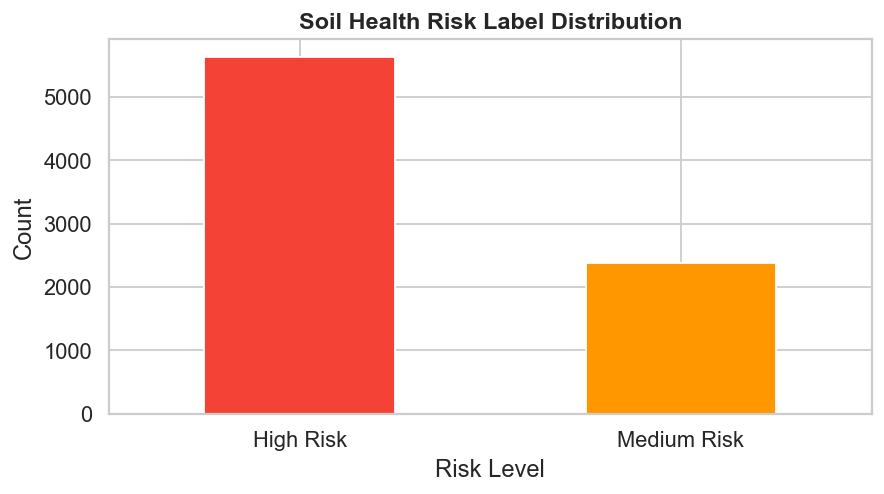

Soil_Risk
High Risk      5629
Medium Risk    2371
Name: count, dtype: int64


In [32]:
# EDA: Soil Risk Label Distribution
fig, ax = plt.subplots(figsize=(7, 4))
risk_counts = df_model["Soil_Risk"].value_counts()
colors = {"Low Risk": "#4CAF50", "Medium Risk": "#FF9800", "High Risk": "#F44336"}
risk_counts.plot(kind="bar", color=[colors[k] for k in risk_counts.index], ax=ax, edgecolor="white")
ax.set_title("Soil Health Risk Label Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../visualizations/soil_prediction/eda/08_soil_risk_distribution.png")
plt.show()

print(risk_counts)

In [35]:
# Helper: Model Comparison & Plotting Utilities
def compare_classifiers(X_train, X_test, y_train, y_test, task_name, label_names=None):
    """Train multiple classifiers and return a comparison DataFrame."""
    models = {
        "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree"        : DecisionTreeClassifier(random_state=42),
        "Random Forest"        : RandomForestClassifier(n_estimators=200, random_state=42),
        "SVM"                  : SVC(probability=True, random_state=42),
        "KNN"                  : KNeighborsClassifier(n_neighbors=7),
        "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=150, random_state=42),
        "XGBoost"              : XGBClassifier(n_estimators=150, use_label_encoder=False,
                                               eval_metric="mlogloss", random_state=42, verbosity=0),
        "LightGBM"             : LGBMClassifier(n_estimators=150, random_state=42, verbosity=-1),
    }

    results = {}
    trained  = {}

    for name, clf in models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        results[name] = {
            "Accuracy" : accuracy_score(y_test, y_pred),
            "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
        }
        trained[name] = pipe
        print(f"  {name:25s}  Acc={results[name]['Accuracy']:.4f}  F1={results[name]['F1 (macro)']:.4f}")

    df_results = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)

    # Bar chart comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax_i, metric in enumerate(["Accuracy", "F1 (macro)"]):
        df_results[metric].sort_values().plot(kind="barh", ax=axes[ax_i], color="#4A90D9", edgecolor="white")
        axes[ax_i].set_xlim(0, 1)
        axes[ax_i].set_title(f"{metric} — {task_name}", fontweight="bold")
        axes[ax_i].axvline(df_results[metric].max(), color="red", linestyle="--", linewidth=1, label="Best")
        axes[ax_i].legend()

    plt.tight_layout()
    safe = task_name.lower().replace(" ", "_")
    plt.savefig(f"../visualizations/soil_prediction/models/{safe}_comparison.png", bbox_inches="tight")
    plt.show()

    # Confusion matrix for best model
    best_name  = df_results["Accuracy"].idxmax()
    best_model = trained[best_name]
    y_pred_best = best_model.predict(X_test)

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
                                            display_labels=label_names,
                                            ax=ax, colorbar=False,
                                            cmap="Blues")
    ax.set_title(f"Confusion Matrix — {best_name} ({task_name})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"../visualizations/soil_prediction/models/{safe}_confusion_matrix.png", bbox_inches="tight")
    plt.show()

    print(f"\nBest model: {best_name}")
    return df_results, trained, best_name


def compare_regressors(X_train, X_test, y_train, y_test, task_name):
    """Train multiple regressors and return a comparison DataFrame."""
    models = {
        "Ridge Regression"  : Ridge(alpha=1.0),
        "Random Forest"     : RandomForestRegressor(n_estimators=200, random_state=42),
        "SVR"               : SVR(kernel="rbf"),
        "Gradient Boosting" : GradientBoostingClassifier(n_estimators=150, random_state=42),
        "XGBoost"           : XGBRegressor(n_estimators=150, random_state=42, verbosity=0),
        "LightGBM"          : LGBMRegressor(n_estimators=150, random_state=42, verbosity=-1),
    }

    results = {}
    trained  = {}

    for name, reg in models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("reg", reg)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        results[name] = {
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R²"  : r2_score(y_test, y_pred),
        }
        trained[name] = pipe
        print(f"  {name:22s}  RMSE={results[name]['RMSE']:.3f}  R²={results[name]['R²']:.4f}")

    df_results = pd.DataFrame(results).T.sort_values("R²", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_results["RMSE"].sort_values(ascending=False).plot(kind="barh", ax=axes[0], color="#E07B54", edgecolor="white")
    axes[0].set_title(f"RMSE — {task_name}", fontweight="bold")

    df_results["R²"].sort_values().plot(kind="barh", ax=axes[1], color="#5BAD6F", edgecolor="white")
    axes[1].set_title(f"R² Score — {task_name}", fontweight="bold")

    plt.tight_layout()
    safe = task_name.lower().replace(" ", "_")
    plt.savefig(f"../visualizations/soil_prediction/models/{safe}_comparison.png", bbox_inches="tight")
    plt.show()

    best_name = df_results["R²"].idxmax()
    print(f"\nBest model: {best_name}")
    return df_results, trained, best_name

# Task 1: Soil Health Risk Classification

TASK 1 — Soil Health & Degradation Risk Classification
  Logistic Regression        Acc=0.9475  F1=0.9363
  Decision Tree              Acc=1.0000  F1=1.0000
  Random Forest              Acc=1.0000  F1=1.0000
  SVM                        Acc=0.9669  F1=0.9607
  KNN                        Acc=0.9513  F1=0.9424
  Gradient Boosting          Acc=1.0000  F1=1.0000
  XGBoost                    Acc=1.0000  F1=1.0000
  LightGBM                   Acc=1.0000  F1=1.0000


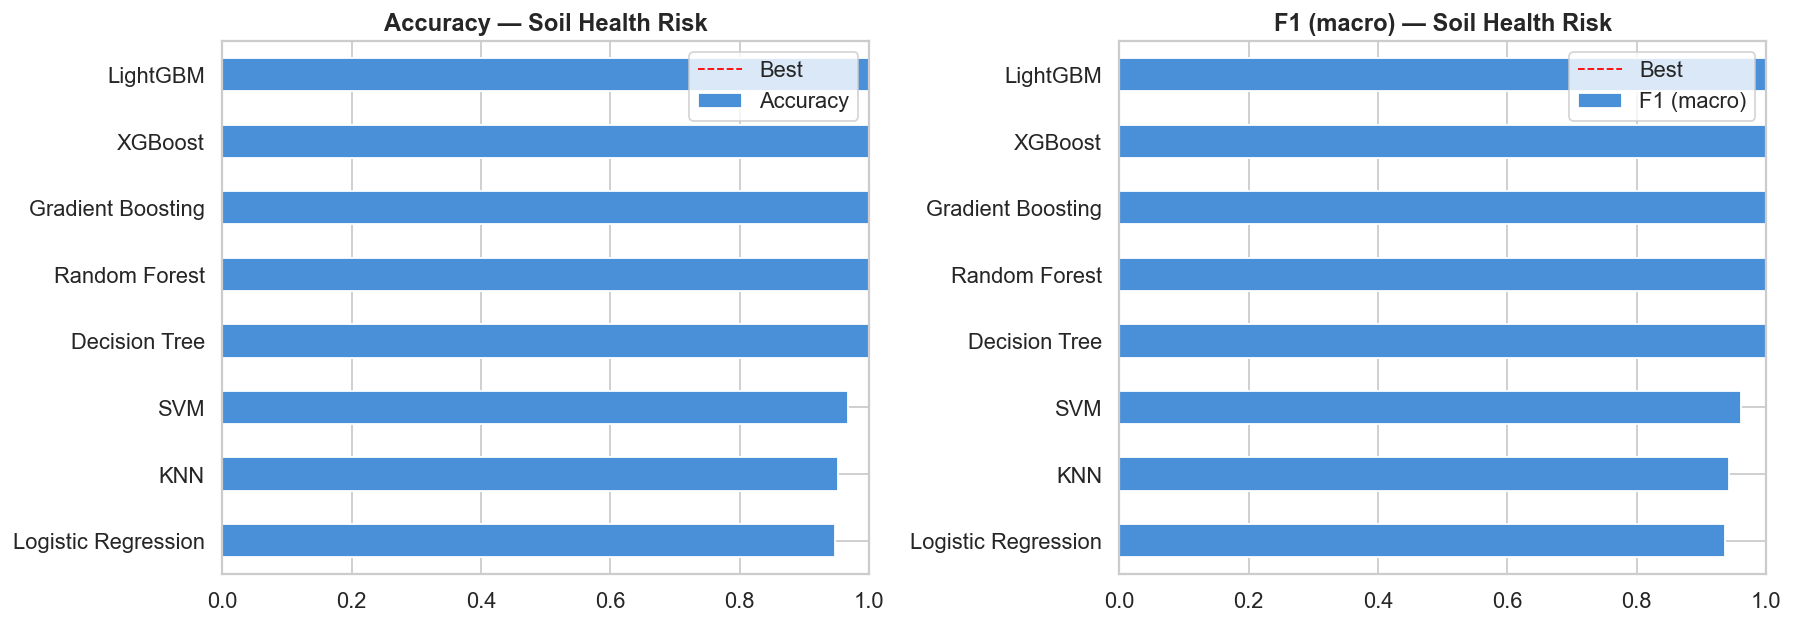

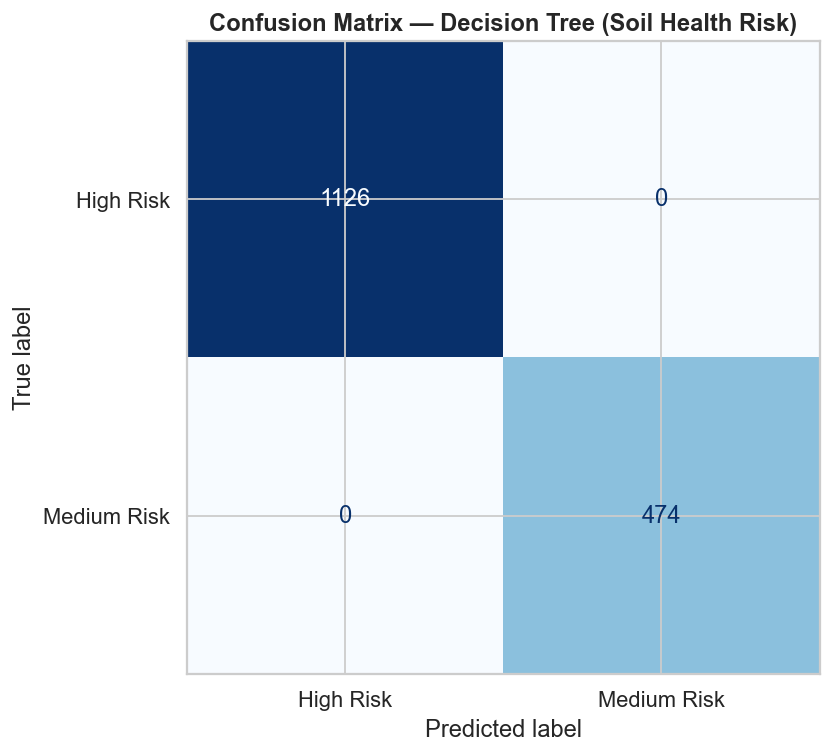


Best model: Decision Tree


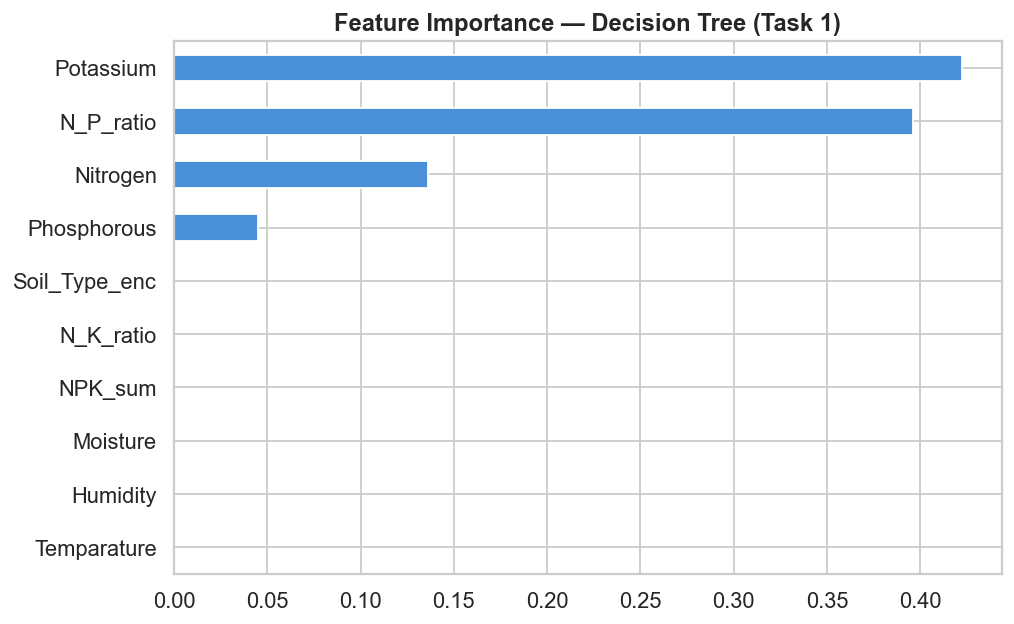


Saved: ../models/soil_prediction/task1_soil_risk_best.pkl  (Decision Tree)


,Accuracy,F1 (macro)
Decision Tree,1.000000,1.000000
Random Forest,1.000000,1.000000
Gradient Boosting,1.000000,1.000000
XGBoost,1.000000,1.000000
LightGBM,1.000000,1.000000
SVM,0.966875,0.960682
KNN,0.951250,0.942372
Logistic Regression,0.947500,0.936337


In [38]:
print("=" * 60)
print("TASK 1 — Soil Health & Degradation Risk Classification")
print("=" * 60)

features_t1 = ["Nitrogen", "Potassium", "Phosphorous",
                "Temparature", "Humidity", "Moisture",
                "NPK_sum", "N_P_ratio", "N_K_ratio",
                "Soil_Type_enc"]

le_risk = LabelEncoder()
X_t1 = df_model[features_t1]
y_t1 = le_risk.fit_transform(df_model["Soil_Risk"])

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_t1, y_t1, test_size=0.2, stratify=y_t1, random_state=42
)

results_t1, trained_t1, best_t1 = compare_classifiers(
    X_train1, X_test1, y_train1, y_test1,
    task_name="Soil Health Risk",
    label_names=le_risk.classes_
)

# Feature importance for tree-based best (if applicable)
best_pipe_t1 = trained_t1[best_t1]
if hasattr(best_pipe_t1["clf"], "feature_importances_"):
    importances = best_pipe_t1["clf"].feature_importances_
    feat_df = pd.Series(importances, index=features_t1).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_df.plot(kind="barh", ax=ax, color="#4A90D9", edgecolor="white")
    ax.set_title(f"Feature Importance — {best_t1} (Task 1)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task1_feature_importance.png", bbox_inches="tight")
    plt.show()

# Save best model
joblib.dump(best_pipe_t1, "../models/soil_prediction/task1_soil_risk_best.pkl")
print(f"\nSaved: ../models/soil_prediction/task1_soil_risk_best.pkl  ({best_t1})")
results_t1

# Task 2: Optimal Crop Recommendation

TASK 2 — Optimal Crop Recommendation
  Logistic Regression        Acc=0.0912  F1=0.0817
  Decision Tree              Acc=0.0844  F1=0.0835
  Random Forest              Acc=0.0887  F1=0.0886
  SVM                        Acc=0.0887  F1=0.0843
  KNN                        Acc=0.0844  F1=0.0810
  Gradient Boosting          Acc=0.0825  F1=0.0822
  XGBoost                    Acc=0.0931  F1=0.0926
  LightGBM                   Acc=0.0963  F1=0.0953


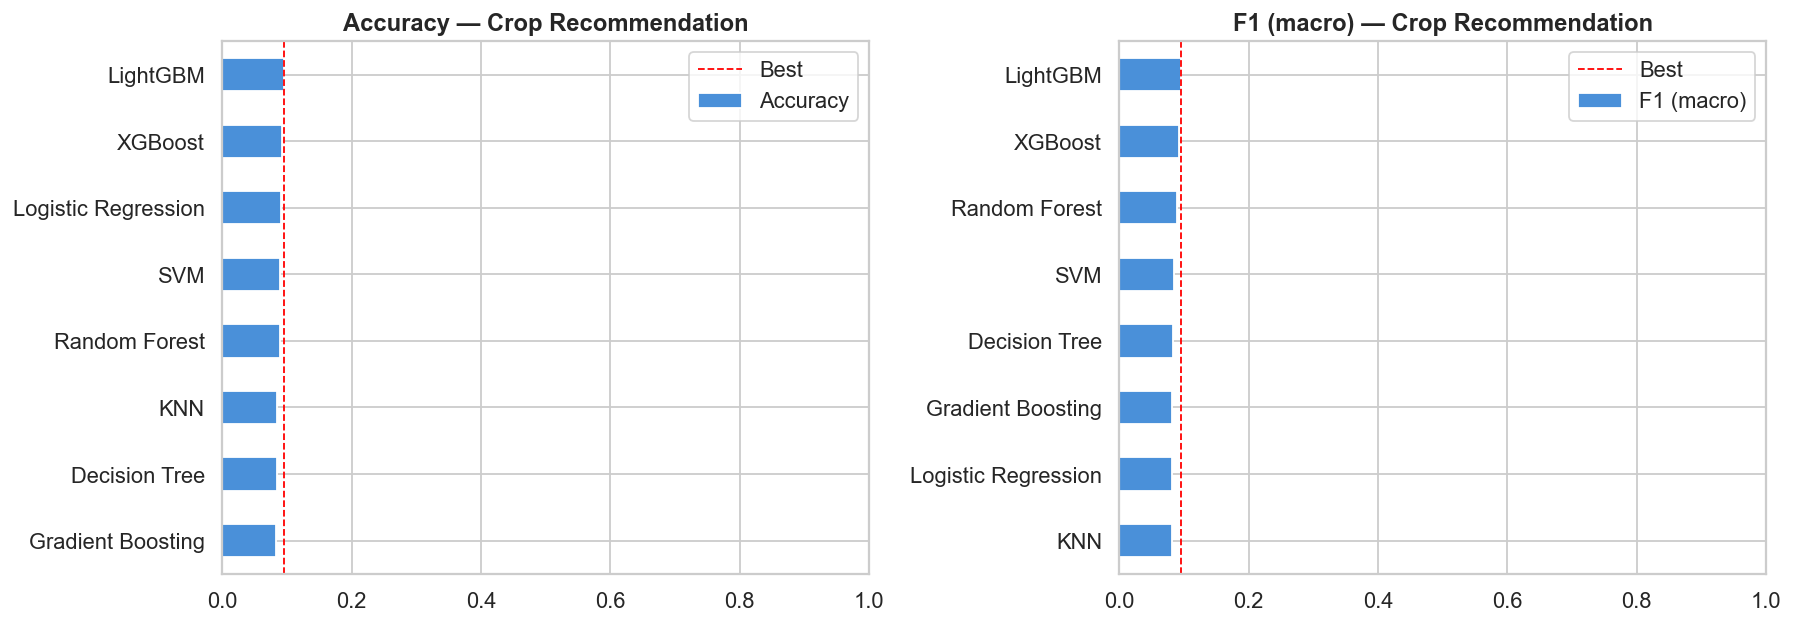

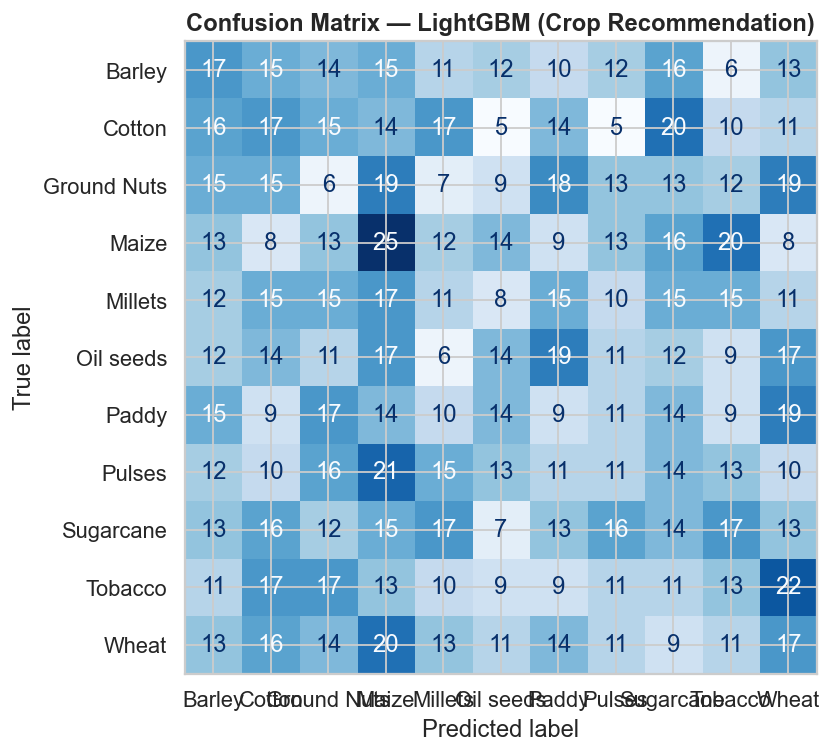


Best model: LightGBM


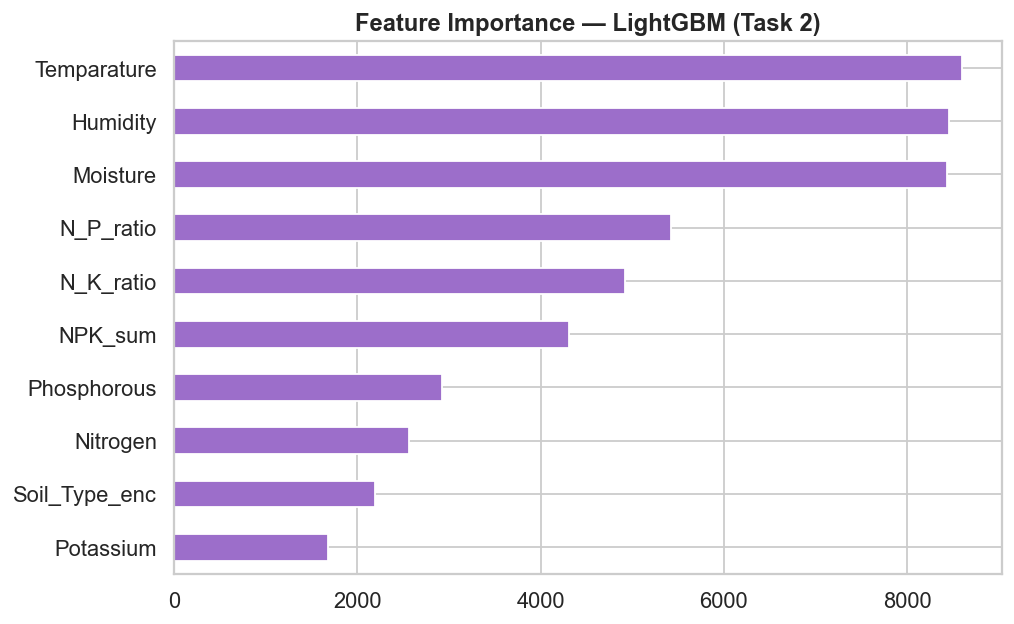


Saved: ../models/soil_prediction/task2_crop_recommendation_best.pkl  (LightGBM)


,Accuracy,F1 (macro)
LightGBM,0.096250,0.095315
XGBoost,0.093125,0.092556
Logistic Regression,0.091250,0.081720
Random Forest,0.088750,0.088566
SVM,0.088750,0.084279
Decision Tree,0.084375,0.083470
KNN,0.084375,0.080999
Gradient Boosting,0.082500,0.082248


In [40]:
print("=" * 60)
print("TASK 2 — Optimal Crop Recommendation")
print("=" * 60)

features_t2 = ["Nitrogen", "Potassium", "Phosphorous",
                "Temparature", "Humidity", "Moisture",
                "NPK_sum", "N_P_ratio", "N_K_ratio",
                "Soil_Type_enc"]

X_t2 = df_model[features_t2]
y_t2 = df_model["Crop_Type_enc"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_t2, y_t2, test_size=0.2, stratify=y_t2, random_state=42
)

results_t2, trained_t2, best_t2 = compare_classifiers(
    X_train2, X_test2, y_train2, y_test2,
    task_name="Crop Recommendation",
    label_names=le_crop.classes_
)

best_pipe_t2 = trained_t2[best_t2]

# Feature importance
if hasattr(best_pipe_t2["clf"], "feature_importances_"):
    importances = best_pipe_t2["clf"].feature_importances_
    feat_df = pd.Series(importances, index=features_t2).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_df.plot(kind="barh", ax=ax, color="#9C6ECA", edgecolor="white")
    ax.set_title(f"Feature Importance — {best_t2} (Task 2)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task2_feature_importance.png", bbox_inches="tight")
    plt.show()

# Save
joblib.dump(best_pipe_t2, "../models/soil_prediction/task2_crop_recommendation_best.pkl")
print(f"\nSaved: ../models/soil_prediction/task2_crop_recommendation_best.pkl  ({best_t2})")
results_t2

# Task 3a: Fertilizer Prescription (Multi-class Classification)

TASK 3a — Fertilizer Prescription (Classification)
  Logistic Regression        Acc=0.1469  F1=0.1279
  Decision Tree              Acc=0.1437  F1=0.1438
  Random Forest              Acc=0.1363  F1=0.1359
  SVM                        Acc=0.1425  F1=0.1393
  KNN                        Acc=0.1394  F1=0.1378
  Gradient Boosting          Acc=0.1419  F1=0.1415
  XGBoost                    Acc=0.1444  F1=0.1444
  LightGBM                   Acc=0.1419  F1=0.1421


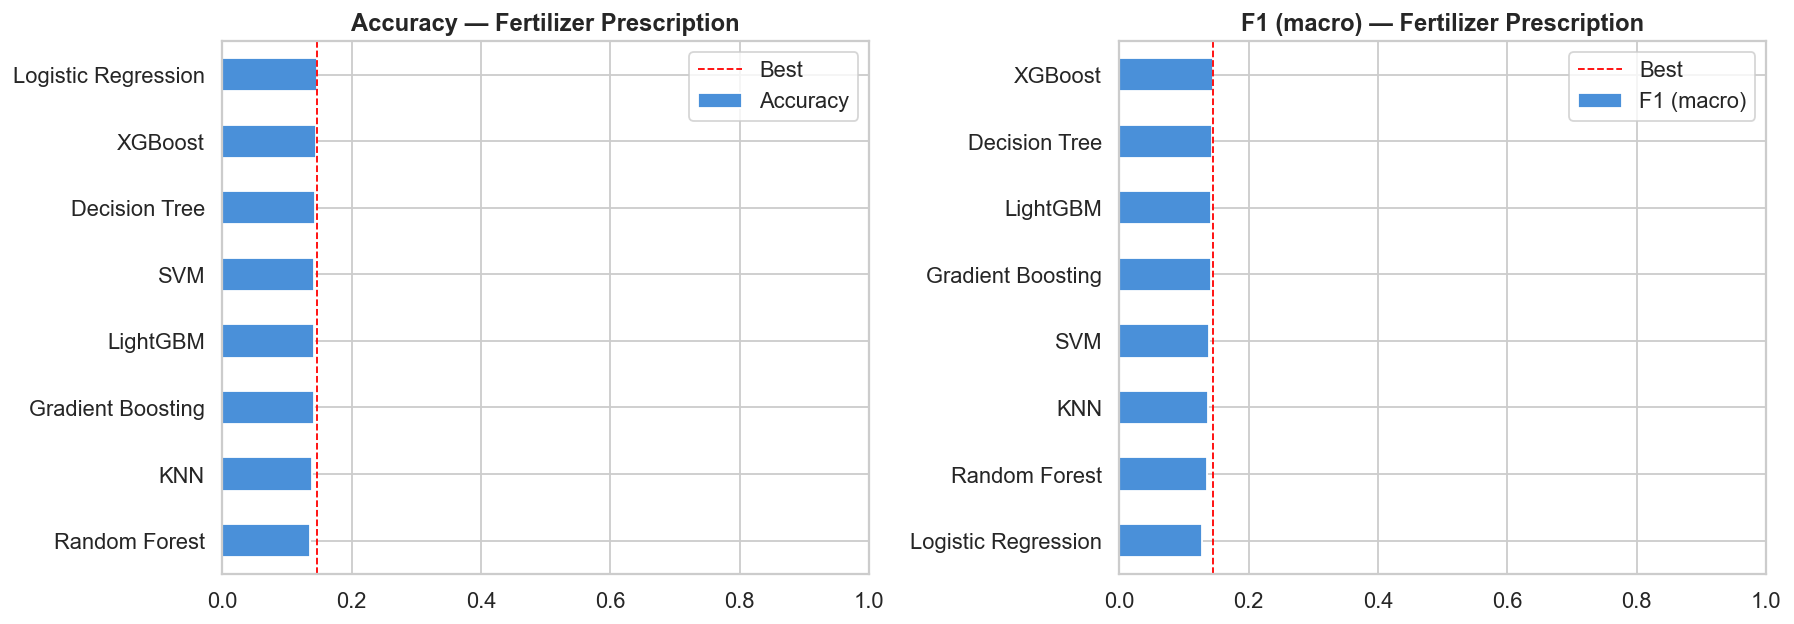

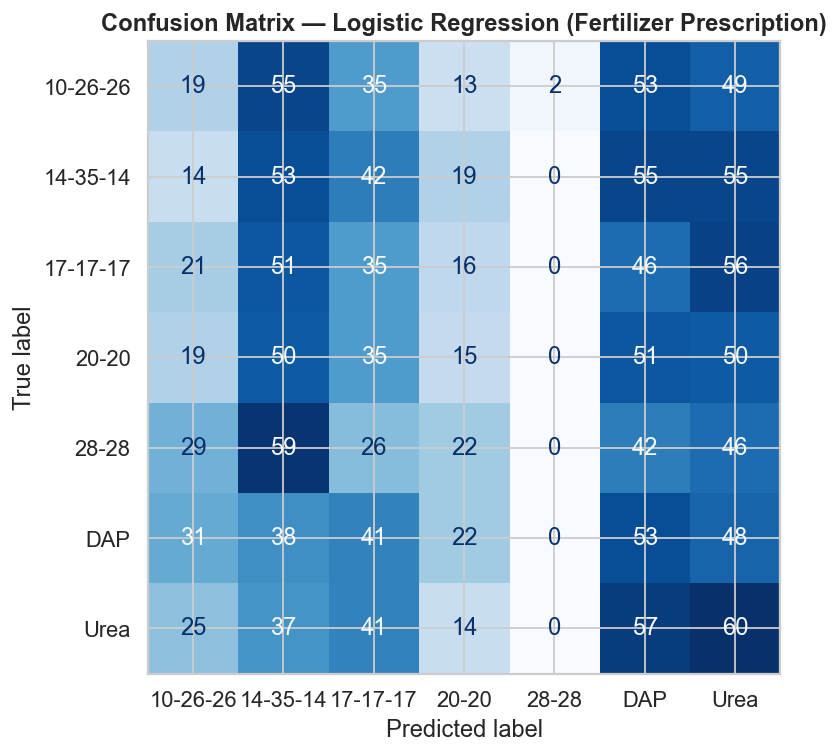


Best model: Logistic Regression

Saved: models/soil_prediction/task3_fertilizer_prescription_best.pkl  (Logistic Regression)


,Accuracy,F1 (macro)
Logistic Regression,0.146875,0.127935
XGBoost,0.144375,0.144361
Decision Tree,0.143750,0.143837
SVM,0.142500,0.139320
Gradient Boosting,0.141875,0.141451
LightGBM,0.141875,0.142112
KNN,0.139375,0.137846
Random Forest,0.136250,0.135881


In [42]:
print("=" * 60)
print("TASK 3a — Fertilizer Prescription (Classification)")
print("=" * 60)

features_t3 = ["Nitrogen", "Potassium", "Phosphorous",
                "Temparature", "Humidity", "Moisture",
                "NPK_sum", "N_P_ratio", "N_K_ratio",
                "Soil_Type_enc", "Crop_Type_enc"]

X_t3 = df_model[features_t3]
y_t3 = df_model["Fert_Name_enc"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_t3, y_t3, test_size=0.2, stratify=y_t3, random_state=42
)

results_t3, trained_t3, best_t3 = compare_classifiers(
    X_train3, X_test3, y_train3, y_test3,
    task_name="Fertilizer Prescription",
    label_names=le_fert.classes_
)

best_pipe_t3 = trained_t3[best_t3]

if hasattr(best_pipe_t3["clf"], "feature_importances_"):
    importances = best_pipe_t3["clf"].feature_importances_
    feat_df = pd.Series(importances, index=features_t3).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_df.plot(kind="barh", ax=ax, color="#E07B54", edgecolor="white")
    ax.set_title(f"Feature Importance — {best_t3} (Task 3)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task3_feature_importance.png", bbox_inches="tight")
    plt.show()

joblib.dump(best_pipe_t3, "../models/soil_prediction/task3_fertilizer_prescription_best.pkl")
print(f"\nSaved: models/soil_prediction/task3_fertilizer_prescription_best.pkl  ({best_t3})")
results_t3

# Task 3b: Nutrient Regression (N, P, K)

TASK 3b — Nutrient Regression (predict required N, P, K levels)

--- Predicting: Nitrogen ---
  Ridge Regression        RMSE=11.741  R²=0.0095
  Random Forest           RMSE=11.916  R²=-0.0204
  SVR                     RMSE=12.056  R²=-0.0445
  Gradient Boosting       RMSE=16.042  R²=-0.8493
  XGBoost                 RMSE=12.838  R²=-0.1844
  LightGBM                RMSE=11.998  R²=-0.0345


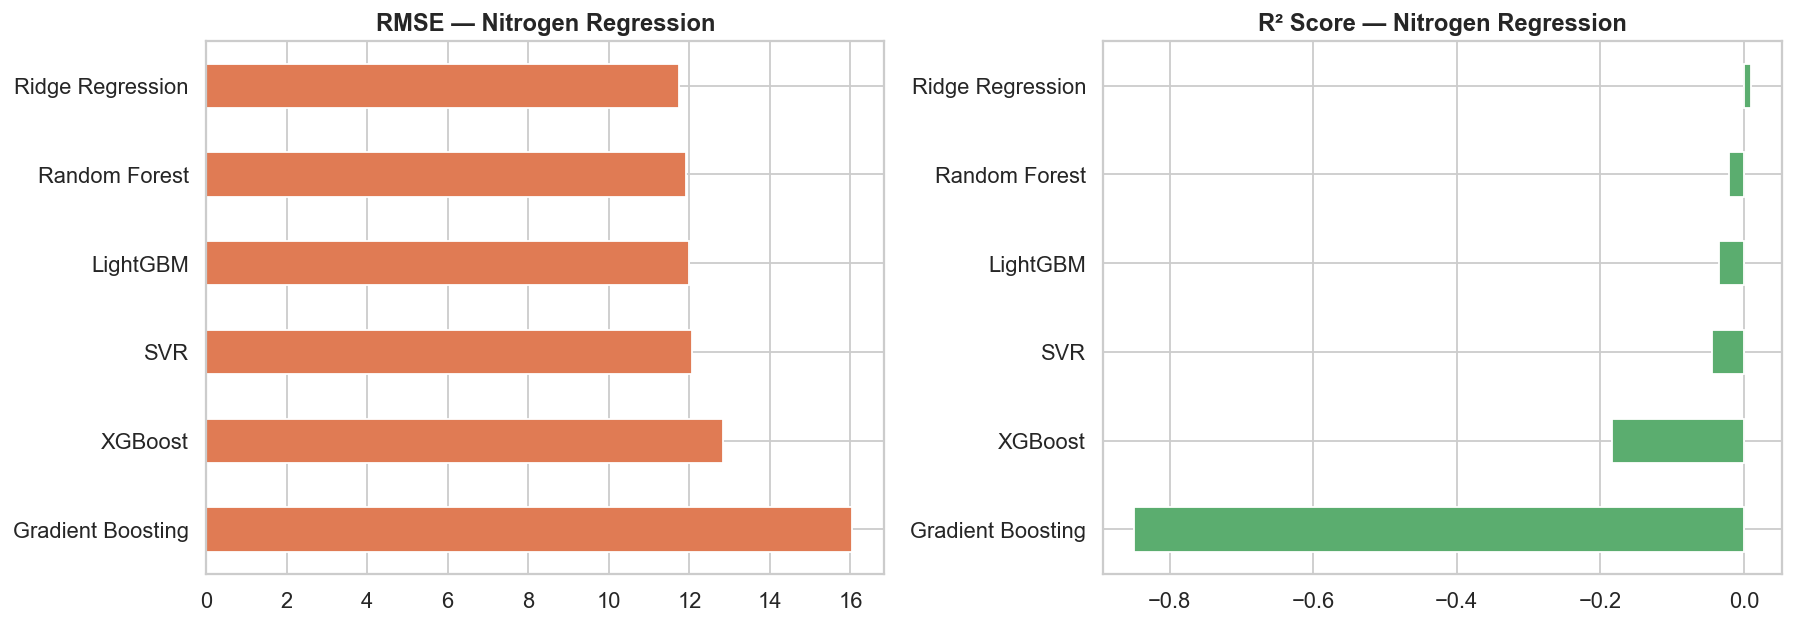


Best model: Ridge Regression


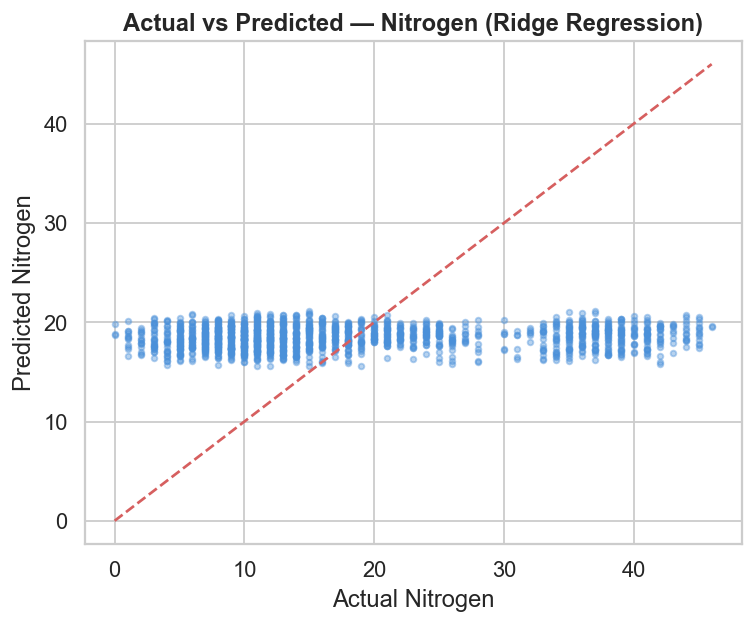

  Saved: models/soil_prediction/task3b_nitrogen_regression_best.pkl  (Ridge Regression)

--- Predicting: Potassium ---
  Ridge Regression        RMSE=5.487  R²=-0.0009
  Random Forest           RMSE=5.562  R²=-0.0283
  SVR                     RMSE=5.921  R²=-0.1657
  Gradient Boosting       RMSE=7.375  R²=-0.8084
  XGBoost                 RMSE=5.907  R²=-0.1598
  LightGBM                RMSE=5.566  R²=-0.0298


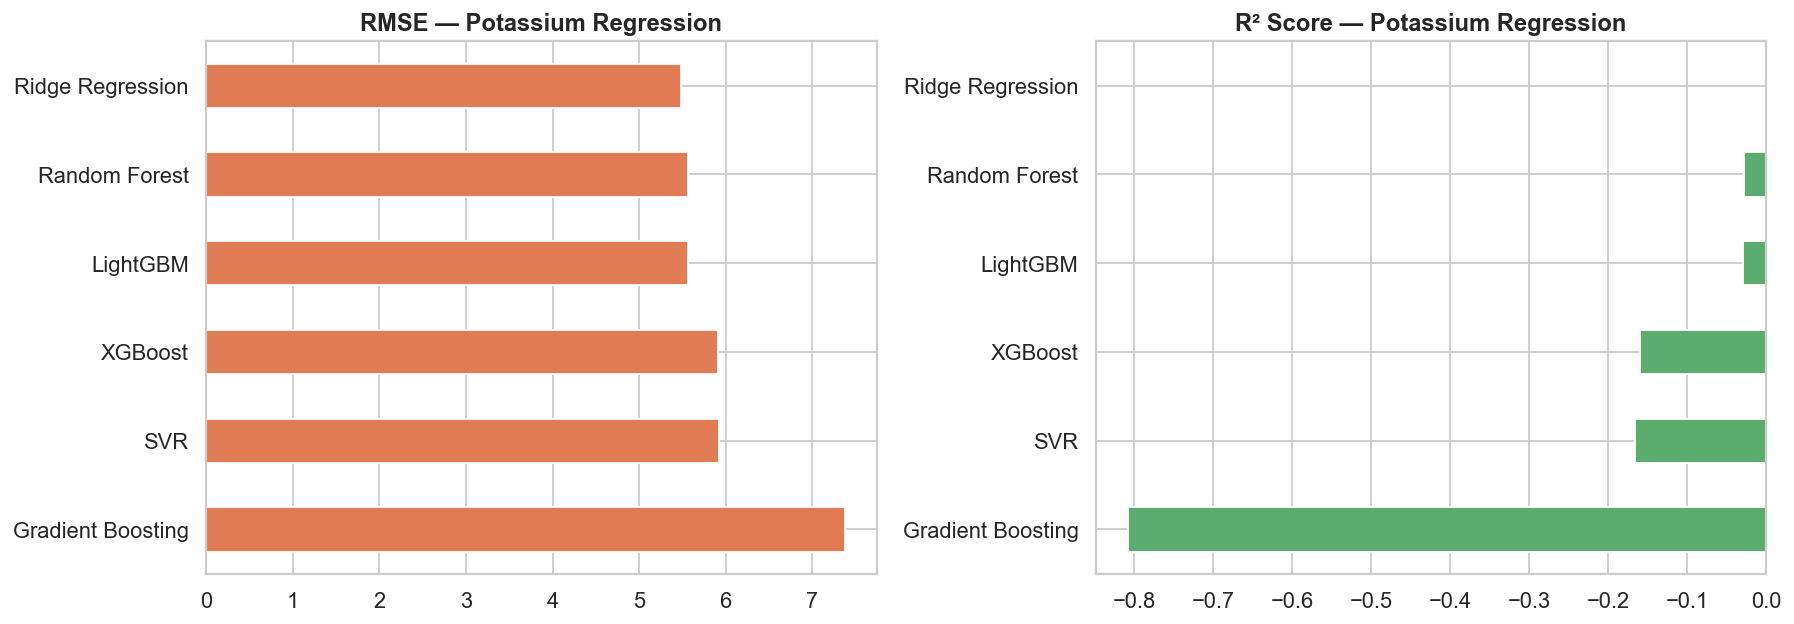


Best model: Ridge Regression


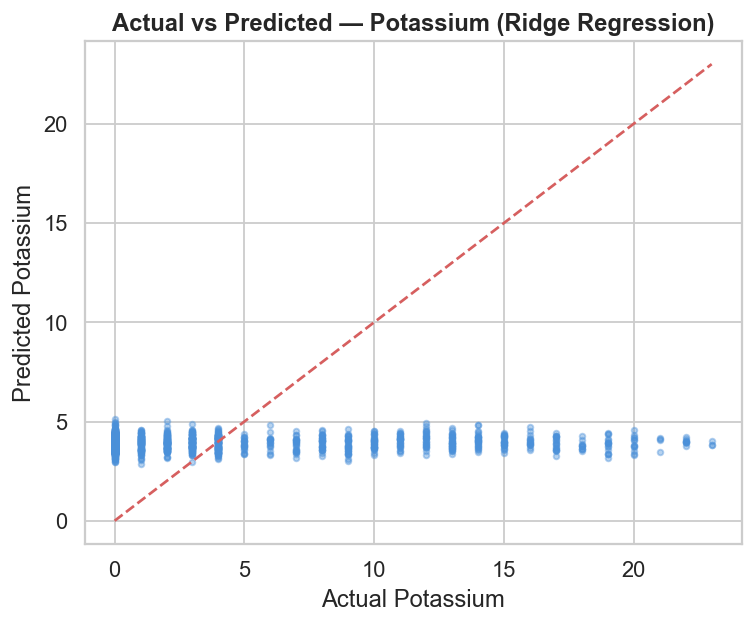

  Saved: models/soil_prediction/task3b_potassium_regression_best.pkl  (Ridge Regression)

--- Predicting: Phosphorous ---
  Ridge Regression        RMSE=12.942  R²=0.0435
  Random Forest           RMSE=13.065  R²=0.0253
  SVR                     RMSE=12.956  R²=0.0415
  Gradient Boosting       RMSE=20.288  R²=-1.3504
  XGBoost                 RMSE=13.933  R²=-0.1085
  LightGBM                RMSE=13.089  R²=0.0218


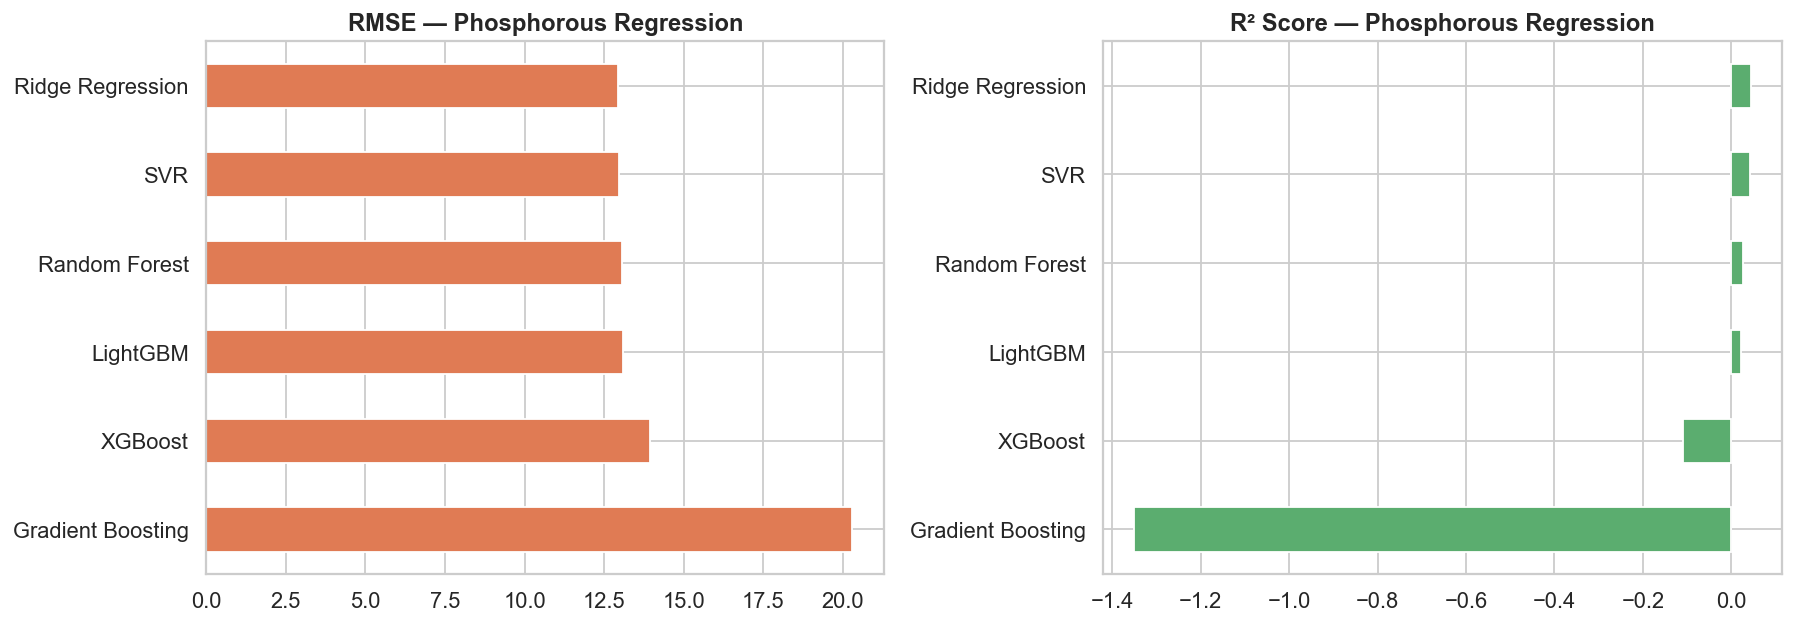


Best model: Ridge Regression


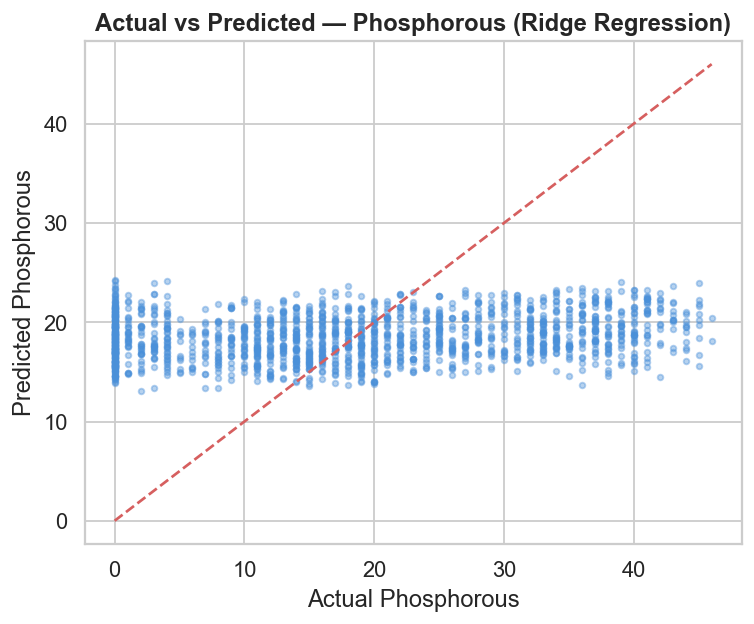

  Saved: models/soil_prediction/task3b_phosphorous_regression_best.pkl  (Ridge Regression)


In [43]:
print("=" * 60)
print("TASK 3b — Nutrient Regression (predict required N, P, K levels)")
print("=" * 60)

features_reg = ["Temparature", "Humidity", "Moisture",
                 "Soil_Type_enc", "Crop_Type_enc"]

for nutrient in ["Nitrogen", "Potassium", "Phosphorous"]:
    print(f"\n--- Predicting: {nutrient} ---")
    X_r = df_model[features_reg]
    y_r = df_model[nutrient]

    X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2, random_state=42)
    results_r, trained_r, best_r = compare_regressors(X_tr, X_te, y_tr, y_te, task_name=f"{nutrient} Regression")

    best_pipe_r = trained_r[best_r]

    # Actual vs Predicted scatter
    y_pred_r = best_pipe_r.predict(X_te)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_te, y_pred_r, alpha=0.4, s=10, color="#4A90D9")
    ax.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], "r--", lw=1.5)
    ax.set_xlabel(f"Actual {nutrient}")
    ax.set_ylabel(f"Predicted {nutrient}")
    ax.set_title(f"Actual vs Predicted — {nutrient} ({best_r})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"../visualizations/soil_prediction/models/task3b_{nutrient.lower()}_actual_vs_pred.png", bbox_inches="tight")
    plt.show()

    joblib.dump(best_pipe_r, f"../models/soil_prediction/task3b_{nutrient.lower()}_regression_best.pkl")
    print(f"  Saved: models/soil_prediction/task3b_{nutrient.lower()}_regression_best.pkl  ({best_r})")

# Task 4: Soil Salinity & Stress Index

TASK 4 — Soil Salinity & Stress Index Classification
Class balance:
Salinity_Stress
0    7550
1     450
Name: count, dtype: int64
  Logistic Regression        Acc=0.9675  F1=0.8348
  Decision Tree              Acc=1.0000  F1=1.0000
  Random Forest              Acc=0.9994  F1=0.9970
  SVM                        Acc=0.9825  F1=0.9149
  KNN                        Acc=0.9731  F1=0.8506
  Gradient Boosting          Acc=1.0000  F1=1.0000
  XGBoost                    Acc=0.9994  F1=0.9970
  LightGBM                   Acc=0.9975  F1=0.9881


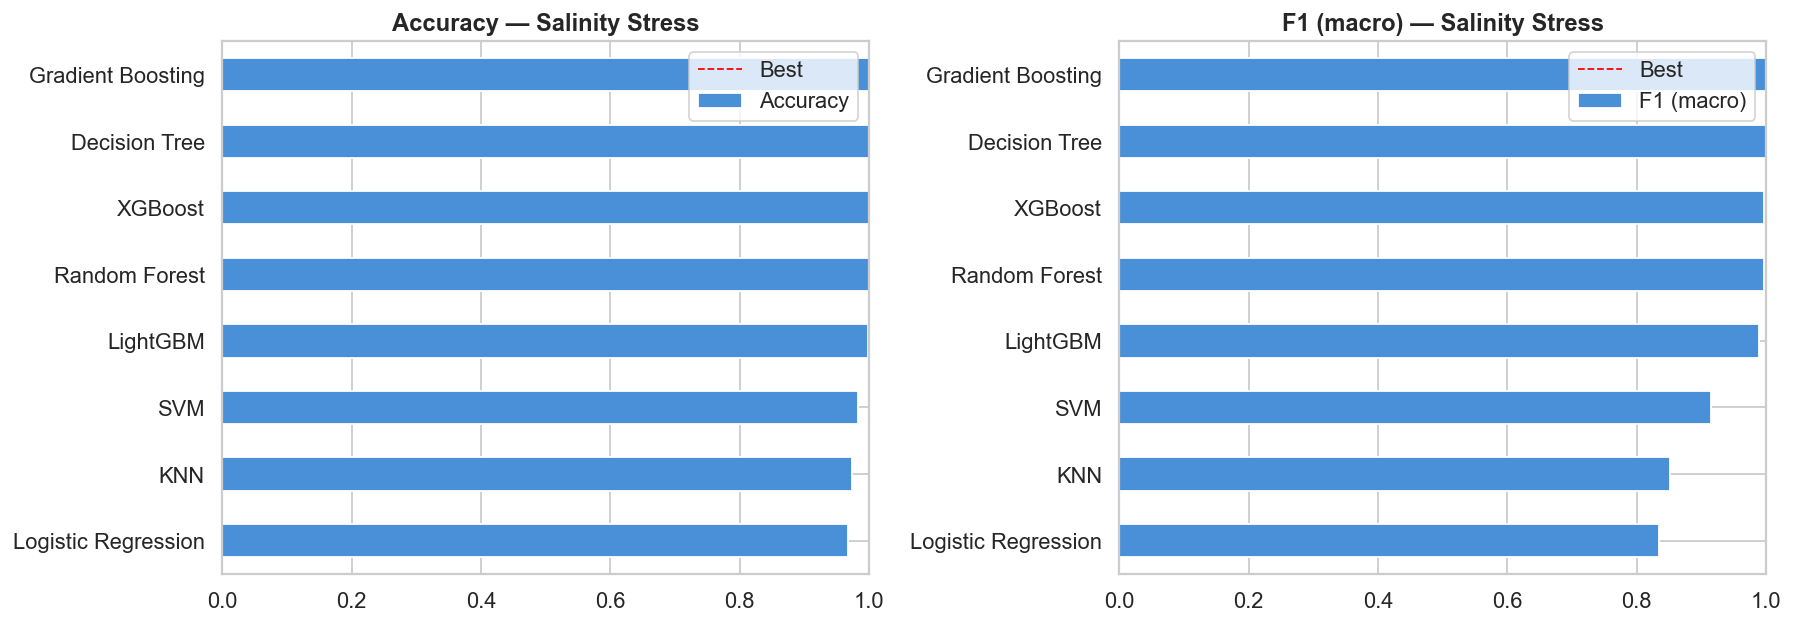

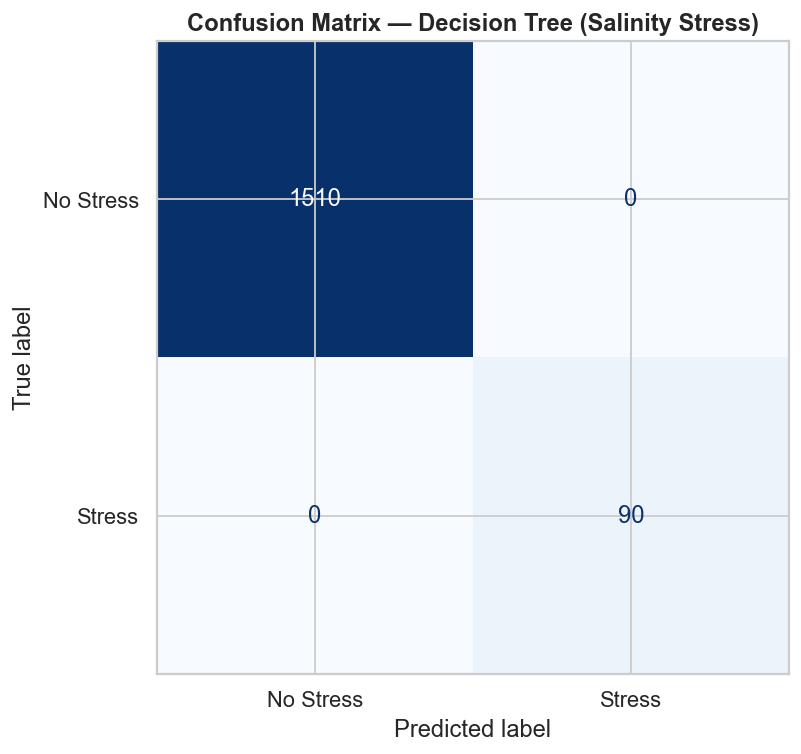


Best model: Decision Tree


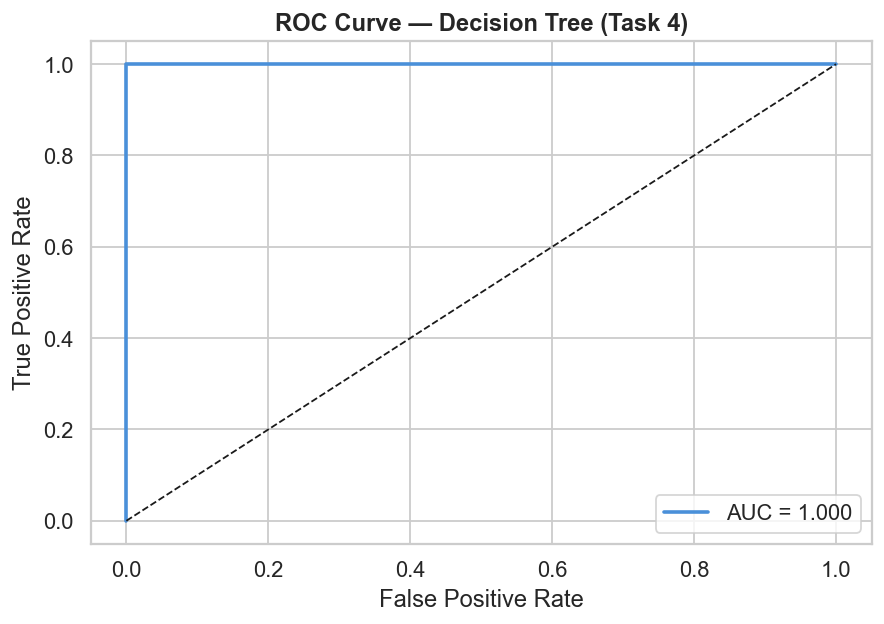

ROC AUC: 1.0000

Saved: modelssoil_prediction//task4_salinity_stress_best.pkl  (Decision Tree)


,Accuracy,F1 (macro)
Decision Tree,1.000000,1.000000
Gradient Boosting,1.000000,1.000000
Random Forest,0.999375,0.997041
XGBoost,0.999375,0.997041
LightGBM,0.997500,0.988102
SVM,0.982500,0.914914
KNN,0.973125,0.850564
Logistic Regression,0.967500,0.834804


In [45]:
print("=" * 60)
print("TASK 4 — Soil Salinity & Stress Index Classification")
print("=" * 60)

features_t4 = ["Nitrogen", "Potassium", "Phosphorous",
                "Temparature", "Humidity", "Moisture",
                "NPK_sum", "Soil_Type_enc", "Crop_Type_enc"]

X_t4 = df_model[features_t4]
y_t4 = df_model["Salinity_Stress"]

print(f"Class balance:\n{y_t4.value_counts()}")

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_t4, y_t4, test_size=0.2, stratify=y_t4, random_state=42
)

results_t4, trained_t4, best_t4 = compare_classifiers(
    X_train4, X_test4, y_train4, y_test4,
    task_name="Salinity Stress",
    label_names=["No Stress", "Stress"]
)

best_pipe_t4 = trained_t4[best_t4]

# ROC Curve
if hasattr(best_pipe_t4["clf"], "predict_proba"):
    y_prob = best_pipe_t4.predict_proba(X_test4)[:, 1]
    fpr, tpr, _ = roc_curve(y_test4, y_prob)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="#4A90D9", lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {best_t4} (Task 4)", fontweight="bold")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("../visualizations/soil_prediction/models/task4_roc_curve.png", bbox_inches="tight")
    plt.show()
    print(f"ROC AUC: {roc_auc:.4f}")

joblib.dump(best_pipe_t4, "../models/soil_prediction/task4_salinity_stress_best.pkl")
print(f"\nSaved: modelssoil_prediction//task4_salinity_stress_best.pkl  ({best_t4})")
results_t4